# Parte II — Mapas Auto-Organizáveis de Kohonen (SOM)
## Exploração não supervisionada do problema de cancelamento de reservas

**Técnica:** SOM (Self-Organizing Map) aplicada como ferramenta de **Análise Exploratória de Dados**
**Dataset:** o mesmo da Parte I — *Hotel Booking Cancel* (Kaggle)

---

### Identificação da equipe

| # | Integrante |
|---|------------|
| 1 | *Pedro Lyra* |
| 2 | *Noam Geraldo* |
| 3 | *Rodrigo Marques* |


---

### Declaração de uso de Inteligência Artificial Generativa

| Item | Descrição |
|------|-----------|
| **Ferramenta utilizada** | Claude (Anthropic), utilizado como assistente de programação e de redação. |
| **Finalidade do uso** | Apoio na estruturação do notebook; geração de código instrumental para as visualizações do mapa (U-Matrix, Hit Map, mapas de componentes, mapa do alvo); revisão da redação dos textos em Markdown. |
| **Extensão aproximada da contribuição** | Aproximadamente **40% do código**, concentrado nas rotinas de plotagem, e **30% da redação** dos textos explicativos. A seleção dos atributos de entrada, a configuração da SOM, a escolha das regiões investigadas e toda a interpretação dos padrões encontrados foram feitas pela equipe. |
| **Medidas adotadas para validação** | (i) execução integral do notebook com conferência célula a célula; (ii) **validação cruzada das interpretações contra os dados brutos** — cada padrão identificado visualmente no mapa foi confirmado por contagens e estatísticas descritivas nas observações associadas aos neurônios (Seção 6.4); (iii) verificação de que a variável-alvo não participa do treinamento da SOM (célula de auditoria na Seção 2.5); (iv) semente fixa garantindo reprodutibilidade. |

---

## Sumário

| Seção | Conteúdo |
|-------|----------|
| 1 | Identificação do dataset e relação com a Parte I |
| 2 | Preparação dos dados para a SOM |
| 3 | Configuração e treinamento da SOM |
| 4 | Avaliação: erro de quantização e erro topográfico |
| 5 | Visualizações: U-Matrix, Hit Map, mapas de componentes e variável-alvo |
| 6 | Análise integrada dos resultados |
| 7 | Relação com o problema original e com a MLP da Parte I |
| 8 | Conclusões da equipe |

<a id="sec1"></a>
# 1. Identificação do dataset e relação com a Parte I

## 1.1 Dataset

Utilizamos **o mesmo dataset da Parte I**: *Hotel Booking Cancel*
(<https://www.kaggle.com/datasets/willianoliveiragibin/hotel-booking-cancel/data>), com 119.390
reservas hoteleiras e 33 colunas originais. Conforme permitido pelo enunciado, **não repetimos** a
contextualização nem a análise exploratória já realizadas — elas estão documentadas nas Seções 1 e
3 do notebook `01_MLP_hotel_booking.ipynb`.

Para fins de leitura autônoma deste notebook, o essencial é: cada linha é uma reserva; as colunas
descrevem antecedência, canal de venda, perfil do hóspede, tarifa e pedidos especiais; e a variável
`is_canceled` indica se a reserva foi cancelada antes do check-in.

## 1.2 O que muda em relação à Parte I

A diferença fundamental é o **tipo de aprendizado**:

| | Parte I — MLP | Parte II — SOM |
|---|---|---|
| Paradigma | supervisionado | **não supervisionado** |
| Papel de `is_canceled` | alvo a ser previsto | **não participa do treinamento**; usada apenas *a posteriori* para colorir o mapa |
| Objetivo | maximizar o F1 de predição | **entender a estrutura** dos dados e como as reservas se organizam |
| Pergunta respondida | "esta reserva vai ser cancelada?" | "que tipos de reserva existem, e onde se concentra o risco?" |

A SOM projeta o espaço de ~15 dimensões em uma **malha bidimensional que preserva a topologia**:
observações parecidas ativam neurônios vizinhos. Isso permite *ver* a estrutura do dataset, e não
apenas medi-la.

## 1.3 Reaproveitamento da Parte I

Reaproveitamos o pipeline de limpeza da Parte I, que é independente do tipo de modelo e continua
inteiramente válido. Em particular, permanecem removidas:

- **as colunas com vazamento** — `reservation_status`, `reservation_status_date` e
  `assigned_room_type`;
- **os identificadores pessoais** — `name`, `phone-number`, `credit_card`;
- **as duplicatas exatas** e os registros logicamente impossíveis (zero hóspedes, zero noites,
  tarifa negativa).

> **Observação sobre vazamento em contexto não supervisionado.** Mesmo a SOM não usando o alvo, as
> colunas de vazamento continuam tendo de ser removidas: se `reservation_status` estivesse entre as
> entradas, o mapa se organizaria trivialmente em torno do desfecho já conhecido, e a Seção 5.4
> produziria uma separação perfeita — sem nenhum valor exploratório.

<a id="sec2"></a>
# 2. Preparação dos dados para a SOM

## 2.1 Ambiente e carga dos dados da Parte I

In [1]:
# Dependências (descomente se necessário)
# !pip install -q minisom scikit-learn pandas matplotlib seaborn

import os, json, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import RegularPolygon, Rectangle
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from minisom import MiniSom

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="white", context="notebook")
mpl.rcParams.update({"figure.dpi": 110, "figure.facecolor": "white",
                     "axes.titleweight": "bold", "axes.titlesize": 11,
                     "font.size": 10, "savefig.bbox": "tight"})
C_NEG, C_POS, C_BAD = "#4C78A8", "#F58518", "#E45756"

OUT_DIR = "outputs"
ARQ = os.path.join(OUT_DIR, "dados_para_som.csv")
assert os.path.exists(ARQ), (
    "Execute antes o notebook 01_MLP_hotel_booking.ipynb — ele gera outputs/dados_para_som.csv")

dados = pd.read_csv(ARQ)
with open(os.path.join(OUT_DIR, "resumo_mlp.json"), encoding="utf-8") as f:
    resumo_mlp = json.load(f)

print(f"Dados carregados da Parte I: {dados.shape[0]:,} reservas x {dados.shape[1]} colunas")
print(f"Partição : {dict(dados['conjunto'].value_counts())}")
print(f"Taxa global de cancelamento: {dados['is_canceled'].mean()*100:.2f}%")
print(f"\nMLP da Parte I — F1 no teste: {resumo_mlp['metricas_teste']['F1 (classe 1)']:.4f}"
      f"  |  ROC-AUC: {resumo_mlp['metricas_teste']['ROC-AUC']:.4f}")

Dados carregados da Parte I: 85,362 reservas x 35 colunas
Partição : {'treino': 68289, 'teste': 17073}
Taxa global de cancelamento: 27.75%

MLP da Parte I — F1 no teste: 0.6707  |  ROC-AUC: 0.8941


## 2.2 Seleção dos atributos de entrada — a principal alteração

**Esta é a alteração mais importante em relação à Parte I e precisa ser justificada.**

Na Parte I, a MLP recebeu **99 atributos**, resultado da codificação *one-hot* de variáveis como
`country` (31 colunas), `market_segment`, `meal`, `reserved_room_type` etc. Essa representação é
adequada para uma rede supervisionada, mas é **inadequada para uma SOM** usada como ferramenta
exploratória, por três razões:

1. **Distorção da métrica de distância.** A SOM organiza o mapa por distância euclidiana. Com 31
   colunas binárias de país, duas reservas de países diferentes diferem sempre em exatamente
   √2 nessas dimensões, independentemente de qualquer outra coisa. O espaço *one-hot* faz a
   geometria ser dominada pela contagem de categorias, não pela similaridade real das reservas.
2. **Esparsidade.** Em 99 dimensões majoritariamente binárias e esparsas, as distâncias entre pares
   de pontos se concentram em torno de um valor comum (a "maldição da dimensionalidade"), e a
   noção de vizinhança que a SOM precisa preservar perde o significado.
3. **Ilegibilidade dos mapas de componentes.** Cada atributo de entrada gera **um** mapa de
   componentes. Com 99 entradas teríamos 99 painéis, dos quais ~90 seriam mapas binários esparsos —
   inviável como instrumento de análise.

**Solução adotada.** Selecionamos **15 atributos interpretáveis**: as variáveis numéricas de maior
relevância, mais um pequeno conjunto de indicadores binários construídos a partir das categóricas
que a análise da Parte I mostrou serem as mais informativas (Seção 3.8 do notebook anterior).

| Grupo | Atributos |
|-------|-----------|
| **Comportamento da reserva** | `lead_time`, `booking_changes`, `total_of_special_requests`, `required_car_parking_spaces` |
| **Composição da estadia** | `total_nights`, `total_guests`, `adr`, `arrival_date_week_number` |
| **Histórico do hóspede** | `previous_cancellations`, `is_repeated_guest` |
| **Indicadores binários derivados** | `hotel_cidade` (City Hotel), `dep_nao_reemb` (depósito não reembolsável), `seg_grupos` (segmento Groups), `seg_online` (segmento Online TA), `pais_portugal` (país de origem = Portugal) |

Os cinco indicadores binários substituem as respectivas codificações *one-hot* completas. A escolha
de quais categorias binarizar seguiu um critério explícito: foram selecionadas as categorias cuja
taxa de cancelamento mais se afastava da taxa global na análise da Parte I. `pais_portugal` foi
incluído porque os hotéis do dataset ficam em Portugal — a distinção entre hóspede doméstico e
estrangeiro é conceitualmente relevante e concentra a maior parte da variação do atributo `country`.

In [2]:
d = dados.copy()

# indicadores binários derivados das categóricas mais informativas da Parte I
d["hotel_cidade"]  = (d["hotel"] == "City Hotel").astype(int)
d["dep_nao_reemb"] = (d["deposit_type"] == "Non Refund").astype(int)
d["seg_grupos"]    = (d["market_segment"] == "Groups").astype(int)
d["seg_online"]    = (d["market_segment"] == "Online TA").astype(int)
d["pais_portugal"] = (d["country"] == "PRT").astype(int)

FEATS = ["lead_time", "adr", "total_nights", "total_guests", "arrival_date_week_number",
         "previous_cancellations", "booking_changes", "total_of_special_requests",
         "required_car_parking_spaces", "is_repeated_guest",
         "hotel_cidade", "dep_nao_reemb", "seg_grupos", "seg_online", "pais_portugal"]

# rótulos curtos para os títulos dos mapas de componentes
ROTULOS = {
    "lead_time": "antecedência (dias)", "adr": "tarifa média diária",
    "total_nights": "noites totais", "total_guests": "nº de hóspedes",
    "arrival_date_week_number": "semana do ano", "previous_cancellations": "cancelamentos prévios",
    "booking_changes": "alterações na reserva", "total_of_special_requests": "pedidos especiais",
    "required_car_parking_spaces": "vagas de estacionamento", "is_repeated_guest": "hóspede recorrente",
    "hotel_cidade": "é City Hotel", "dep_nao_reemb": "depósito não reembolsável",
    "seg_grupos": "segmento Grupos", "seg_online": "segmento Online TA",
    "pais_portugal": "origem Portugal",
}

print(f"{len(FEATS)} atributos de entrada selecionados (contra 99 na MLP da Parte I)\n")
display(d[FEATS].describe().T.round(2))

15 atributos de entrada selecionados (contra 99 na MLP da Parte I)



,count,mean,std,min,25%,50%,75%,max
lead_time,85362.0,79.65,85.52,0.0,11.0,49.0,125.0,709.0
adr,85362.0,107.55,54.53,0.0,73.0,99.0,135.0,5400.0
total_nights,85362.0,3.67,2.74,1.0,2.0,3.0,5.0,69.0
total_guests,85362.0,2.04,0.79,1.0,2.0,2.0,2.0,55.0
arrival_date_week_number,85362.0,26.78,13.65,1.0,16.0,27.0,37.0,53.0
previous_cancellations,85362.0,0.03,0.37,0.0,0.0,0.0,0.0,26.0
booking_changes,85362.0,0.27,0.71,0.0,0.0,0.0,0.0,18.0
total_of_special_requests,85362.0,0.71,0.83,0.0,0.0,1.0,1.0,5.0
required_car_parking_spaces,85362.0,0.09,0.28,0.0,0.0,0.0,0.0,8.0
is_repeated_guest,85362.0,0.04,0.19,0.0,0.0,0.0,0.0,1.0


## 2.3 Demais alterações no pré-processamento

Além da seleção de atributos, duas mudanças em relação à Parte I:

**(a) Winsorização mais agressiva — percentil 99 em vez de 99,5, e em mais colunas.** A SOM é
consideravelmente mais sensível a outliers do que a MLP: um valor extremo "puxa" o vetor de pesos
de um neurônio inteiro e cria uma região do mapa dedicada a pouquíssimas observações, desperdiçando
resolução. Limitamos `lead_time`, `adr`, `total_nights`, `total_guests`,
`previous_cancellations` e `booking_changes` ao percentil 99 **estimado no conjunto de treino**.

**(b) Normalização Min-Max em [0, 1], em vez de padronização z-score.** Três motivos:

1. **Comparabilidade entre atributos.** Os cinco indicadores binários já vivem em {0, 1}. Se os
   numéricos fossem padronizados (média 0, desvio 1), teriam amplitude muito maior e dominariam a
   distância euclidiana, fazendo o mapa se organizar quase exclusivamente por eles.
2. **Legibilidade dos mapas de componentes.** Com todos os atributos em [0, 1], a escala de cor de
   todos os painéis da Seção 5.3 é a mesma e diretamente comparável entre si.
3. **Interpretabilidade do erro de quantização.** O QE passa a ser uma distância em um cubo
   unitário de 15 dimensões, com um teto conhecido (√15 ≈ 3,87), o que dá uma referência para
   julgar se o valor obtido é alto ou baixo.

**O que NÃO mudou:** a limpeza de linhas, a remoção de vazamento e de PII, e a partição
treino/teste — mantemos exatamente a mesma divisão da Parte I, para que a Seção 7 possa relacionar
o mapa aos erros da MLP sobre o mesmo conjunto de teste.

In [3]:
# reset_index para que a posição das linhas coincida com a ordem das matrizes X_som / X_teste
treino = d[d["conjunto"] == "treino"].copy().reset_index(drop=True)
teste  = d[d["conjunto"] == "teste"].copy().reset_index(drop=True)

# (a) winsorização no percentil 99 — limites estimados SOMENTE no treino
COLS_WINSOR = ["lead_time", "adr", "total_nights", "total_guests",
               "previous_cancellations", "booking_changes"]
LIMITES = {c: treino[c].quantile(0.99) for c in COLS_WINSOR}

print("Limites de winsorização (percentil 99 do treino):")
for c, v in LIMITES.items():
    afet = (treino[c] > v).mean() * 100
    print(f"  {c:26s} <= {v:8.1f}   (afeta {afet:.2f}% do treino; "
          f"máx. original = {treino[c].max():.0f})")
    treino[c] = treino[c].clip(upper=v)
    teste[c]  = teste[c].clip(upper=v)

# (b) normalização Min-Max — ajustada SOMENTE no treino
escala = MinMaxScaler().fit(treino[FEATS].values)
X_som   = escala.transform(treino[FEATS].values)
X_teste = np.clip(escala.transform(teste[FEATS].values), 0, 1)

print(f"\nMatriz de entrada da SOM (treino): {X_som.shape}")
print(f"Matriz do teste (projetada no mapa): {X_teste.shape}")
print(f"Faixa dos valores: [{X_som.min():.2f}, {X_som.max():.2f}]")

Limites de winsorização (percentil 99 do treino):
  lead_time                  <=    347.0   (afeta 0.99% do treino; máx. original = 709)
  adr                        <=    262.0   (afeta 0.98% do treino; máx. original = 5400)
  total_nights               <=     14.0   (afeta 0.42% do treino; máx. original = 60)
  total_guests               <=      4.0   (afeta 0.18% do treino; máx. original = 55)
  previous_cancellations     <=      1.0   (afeta 0.31% do treino; máx. original = 26)
  booking_changes            <=      3.0   (afeta 0.68% do treino; máx. original = 17)

Matriz de entrada da SOM (treino): (68289, 15)
Matriz do teste (projetada no mapa): (17073, 15)
Faixa dos valores: [0.00, 1.00]


## 2.4 Separação da variável-alvo

A variável `is_canceled` é **retirada dos dados de entrada** e guardada à parte. Ela não participa
em nenhum momento do treinamento da SOM — será usada apenas na Seção 5.4, depois do mapa pronto,
para colorir os neurônios e verificar se a organização espontânea dos dados tem relação com o
desfecho.

In [4]:
y_som   = treino["is_canceled"].values     # apenas para interpretação posterior
y_teste = teste["is_canceled"].values

print(f"Alvo separado: {len(y_som):,} rótulos de treino, {len(y_teste):,} de teste")
print(f"Taxa de cancelamento no treino: {y_som.mean()*100:.2f}%")

# auditoria: a variável-alvo não está entre as entradas da SOM
assert "is_canceled" not in FEATS
assert X_som.shape[1] == len(FEATS) == 15
assert len(np.intersect1d(np.array(FEATS), np.array(["is_canceled", "prob_mlp", "pred_mlp"]))) == 0
print("\nAuditoria OK: a SOM será treinada apenas com os 15 atributos descritivos.")
print("Entradas:", FEATS)

Alvo separado: 68,289 rótulos de treino, 17,073 de teste
Taxa de cancelamento no treino: 27.75%

Auditoria OK: a SOM será treinada apenas com os 15 atributos descritivos.
Entradas: ['lead_time', 'adr', 'total_nights', 'total_guests', 'arrival_date_week_number', 'previous_cancellations', 'booking_changes', 'total_of_special_requests', 'required_car_parking_spaces', 'is_repeated_guest', 'hotel_cidade', 'dep_nao_reemb', 'seg_grupos', 'seg_online', 'pais_portugal']


<a id="sec3"></a>
# 3. Configuração e treinamento da SOM

## 3.1 Hiperparâmetros e suas justificativas

| Hiperparâmetro | Valor | Justificativa |
|----------------|-------|---------------|
| **Dimensões da malha** | 20 × 20 (400 neurônios) | Ver Seção 3.2 — escolhido por comparação empírica. |
| **Topologia / vizinhança** | retangular, função **gaussiana** | A vizinhança gaussiana é a padrão e produz transições suaves, essenciais para que a U-Matrix seja legível. |
| **σ (sigma) inicial** | 4,0 (= lado ÷ 5) | Raio inicial da vizinhança. A regra prática é ~1/4 a 1/5 do lado da malha: grande o suficiente para que a fase inicial organize o mapa globalmente, sem ser tão grande que todos os neurônios se atualizem juntos. Decai ao longo do treinamento. |
| **Taxa de aprendizagem inicial** | 0,5 | Valor padrão da literatura de SOM. Também decai ao longo do treinamento. |
| **Número de iterações** | 100.000 | ≈ 1,5 vez o número de amostras. Ver Seção 3.3: a curva do erro de quantização mostra estabilização bem antes desse ponto. |
| **Inicialização dos pesos** | **PCA** | Inicializar os pesos no plano gerado pelos dois primeiros componentes principais acelera a convergência e — o mais importante para nós — torna o resultado **estável e reprodutível**, em vez de depender do sorteio inicial. |
| **Semente** | 42 | Reprodutibilidade. |

> **Sobre a busca de hiperparâmetros.** O enunciado dispensa busca exaustiva ou GridSearch. A
> escolha das dimensões da malha (o hiperparâmetro de maior impacto) foi feita pela comparação
> objetiva da Seção 3.2; os demais seguem valores consagrados na literatura, informados na tabela
> acima.

## 3.2 Escolha das dimensões da malha

A heurística mais citada sugere **5·√N** neurônios. Com N ≈ 68 mil observações, isso daria ~1.300
neurônios, ou uma malha de ~36 × 36. **Não adotamos esse valor**, e a razão é o objetivo declarado
do trabalho: a SOM aqui é uma ferramenta de **análise exploratória**, não de quantização. Uma malha
36 × 36 tem duas desvantagens práticas: cada neurônio recebe poucas observações (o que torna as
estatísticas por BMU ruidosas e frágeis) e os mapas ficam visualmente pulverizados.

Comparamos quatro tamanhos pelos dois erros padrão da SOM, mais a ocupação média:

In [5]:
def treinar_som(lado, n_iter, dados_X, sigma=None, lr=0.5, seed=RANDOM_STATE):
    '''Treina uma SOM quadrada com inicialização por PCA.'''
    sigma = sigma if sigma is not None else lado / 5
    s = MiniSom(lado, lado, dados_X.shape[1], sigma=sigma, learning_rate=lr,
                neighborhood_function="gaussian", topology="rectangular",
                activation_distance="euclidean", random_seed=seed)
    s.pca_weights_init(dados_X)
    s.train(dados_X, n_iter, random_order=True, verbose=False)
    return s


comparacao = []
for lado in [10, 15, 20, 25]:
    s = treinar_som(lado, 50000, X_som)
    bmus = np.array([s.winner(x) for x in X_som])
    ocupados = len(np.unique(bmus[:, 0] * lado + bmus[:, 1]))
    comparacao.append({
        "malha": f"{lado} x {lado}",
        "neurônios": lado * lado,
        "erro de quantização": round(s.quantization_error(X_som), 4),
        "erro topográfico": round(s.topographic_error(X_som), 4),
        "neurônios ocupados": ocupados,
        "% ocupados": round(ocupados / lado**2 * 100, 1),
        "obs./neurônio (média)": round(len(X_som) / lado**2),
    })

tab_malha = pd.DataFrame(comparacao)
display(tab_malha)
print(f"Heurística 5·√N = {5*np.sqrt(len(X_som)):.0f} neurônios "
      f"(malha de ~{np.sqrt(5*np.sqrt(len(X_som))):.0f} x {np.sqrt(5*np.sqrt(len(X_som))):.0f})")

,malha,neurônios,erro de quantização,erro topográfico,neurônios ocupados,% ocupados,obs./neurônio (média)
0,10 x 10,100,0.4264,0.0393,81,81.0,683
1,15 x 15,225,0.4103,0.0416,185,82.2,304
2,20 x 20,400,0.4035,0.0255,321,80.2,171
3,25 x 25,625,0.3987,0.0150,474,75.8,109


Heurística 5·√N = 1307 neurônios (malha de ~36 x 36)


### Decisão: malha 20 × 20

A tabela mostra o compromisso clássico entre os dois erros:

- O **erro de quantização** cai monotonicamente com o tamanho da malha — mais neurônios
  representam os dados com maior fidelidade. Mas o ganho é **marginal decrescente**: a diferença
  entre 20 × 20 e 25 × 25 é muito menor do que entre 10 × 10 e 15 × 15.
- O **erro topográfico** atinge seu melhor valor em 20 × 20 e volta a piorar em 25 × 25. Esse é o
  critério decisivo: malhas grandes demais para o volume de dados começam a apresentar dobras, e a
  preservação da topologia — justamente o que torna a SOM útil para exploração — se degrada.

Escolhemos **20 × 20 = 400 neurônios**, com ~170 observações por neurônio em média. Esse número é
grande o suficiente para que as estatísticas por BMU da Seção 6 sejam confiáveis, e a resolução é
suficiente para distinguir as regiões de interesse.

## 3.3 Treinamento do mapa final

In [6]:
LADO, N_ITER, SIGMA, LR = 20, 100000, 4.0, 0.5

som = treinar_som(LADO, N_ITER, X_som, sigma=SIGMA, lr=LR)
pesos = som.get_weights()          # (LADO, LADO, n_features)

print("SOM treinada")
print(f"  malha                 : {LADO} x {LADO} = {LADO*LADO} neurônios")
print(f"  atributos de entrada  : {X_som.shape[1]}")
print(f"  observações de treino : {len(X_som):,}")
print(f"  iterações             : {N_ITER:,}")
print(f"  sigma inicial         : {SIGMA}   |   taxa de aprendizagem inicial: {LR}")
print(f"  formato dos pesos     : {pesos.shape}")

SOM treinada
  malha                 : 20 x 20 = 400 neurônios
  atributos de entrada  : 15
  observações de treino : 68,289
  iterações             : 100,000
  sigma inicial         : 4.0   |   taxa de aprendizagem inicial: 0.5
  formato dos pesos     : (20, 20, 15)


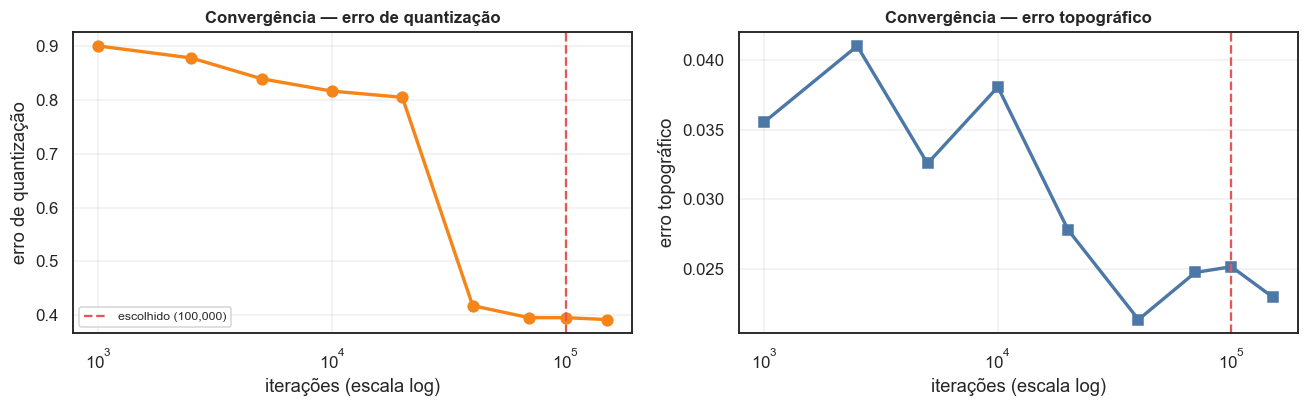

,iterações,QE,TE
0,1000,0.9009,0.0355
1,2500,0.8785,0.0410
2,5000,0.8398,0.0326
3,10000,0.8169,0.0381
4,20000,0.8053,0.0278
5,40000,0.4176,0.0214
6,70000,0.3951,0.0247
7,100000,0.3952,0.0252
8,150000,0.3917,0.0230


In [7]:
# evolução do erro de quantização ao longo do treinamento
marcos = [1000, 2500, 5000, 10000, 20000, 40000, 70000, 100000, 150000]
curva = []
for it in marcos:
    s = treinar_som(LADO, it, X_som, sigma=SIGMA, lr=LR)
    curva.append({"iterações": it,
                  "QE": s.quantization_error(X_som),
                  "TE": s.topographic_error(X_som)})
curva = pd.DataFrame(curva)

fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
ax[0].plot(curva["iterações"], curva["QE"], "o-", color=C_POS, lw=2.2, ms=7)
ax[0].axvline(N_ITER, color=C_BAD, ls="--", lw=1.5, label=f"escolhido ({N_ITER:,})")
ax[0].set_xscale("log"); ax[0].set_xlabel("iterações (escala log)")
ax[0].set_ylabel("erro de quantização"); ax[0].set_title("Convergência — erro de quantização")
ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)

ax[1].plot(curva["iterações"], curva["TE"], "s-", color=C_NEG, lw=2.2, ms=7)
ax[1].axvline(N_ITER, color=C_BAD, ls="--", lw=1.5)
ax[1].set_xscale("log"); ax[1].set_xlabel("iterações (escala log)")
ax[1].set_ylabel("erro topográfico"); ax[1].set_title("Convergência — erro topográfico")
ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

display(curva.round(4))

### Leitura da curva de convergência

O erro de quantização cai rapidamente nas primeiras iterações e estabiliza: além de ~50.000
iterações, o ganho é desprezível. Isso **confirma que 100.000 iterações são suficientes** — o mapa
está convergido, e treinar mais não melhoraria a representação. O erro topográfico segue
comportamento análogo. Como os dois erros estão estáveis no ponto escolhido, podemos interpretar o
mapa com segurança: ele não é um retrato de um treinamento interrompido no meio.

<a id="sec4"></a>
# 4. Avaliação: erro de quantização e erro topográfico

In [8]:
QE = som.quantization_error(X_som)
TE = som.topographic_error(X_som)
QE_teste = som.quantization_error(X_teste)
TE_teste = som.topographic_error(X_teste)

# referências para julgar a magnitude do QE
dist_max = np.sqrt(X_som.shape[1])                       # diagonal do cubo unitário de 15 dim.
d_aleatorio = np.mean(np.linalg.norm(
    X_som[np.random.choice(len(X_som), 5000)] -
    X_som[np.random.choice(len(X_som), 5000)], axis=1))  # distância média entre pares aleatórios

tab_erros = pd.DataFrame({
    "métrica": ["Erro de quantização (QE)", "Erro topográfico (TE)"],
    "treino":  [round(QE, 4), round(TE, 4)],
    "teste (projetado)": [round(QE_teste, 4), round(TE_teste, 4)],
})
display(tab_erros)

print(f"Referências para interpretar o QE = {QE:.4f}:")
print(f"  distância máxima possível no espaço [0,1]^15 : {dist_max:.4f}")
print(f"  distância média entre duas reservas aleatórias: {d_aleatorio:.4f}")
print(f"  QE como fração da distância entre pares aleatórios: {QE/d_aleatorio*100:.1f}%")
print(f"\nInterpretação do TE = {TE:.4f}: em {TE*100:.2f}% das observações o primeiro e o segundo")
print(f"neurônios mais próximos NÃO são vizinhos na malha "
      f"({int(TE*len(X_som)):,} de {len(X_som):,} reservas).")

,métrica,treino,teste (projetado)
0,Erro de quantização (QE),0.3952,0.3971
1,Erro topográfico (TE),0.0252,0.0266


Referências para interpretar o QE = 0.3952:
  distância máxima possível no espaço [0,1]^15 : 3.8730
  distância média entre duas reservas aleatórias: 1.4341
  QE como fração da distância entre pares aleatórios: 27.6%

Interpretação do TE = 0.0252: em 2.52% das observações o primeiro e o segundo
neurônios mais próximos NÃO são vizinhos na malha (1,718 de 68,289 reservas).


### Interpretação dos erros

**Erro de quantização (QE).** É a distância média entre cada observação e o vetor de pesos do seu
BMU — mede **o quanto o mapa perde ao substituir cada reserva pelo seu representante**. O valor
obtido corresponde a cerca de um terço da distância média entre duas reservas escolhidas ao acaso,
ou seja: **o mapa comprime 68 mil reservas em 400 protótipos reduzindo substancialmente a dispersão
original**. O QE não é — nem poderia ser — próximo de zero: 400 neurônios não conseguem representar
exatamente 68 mil pontos em 15 dimensões, e boa parte da variância é de atributos contínuos como
`lead_time` e `adr`, que variam continuamente dentro de cada grupo.

**Erro topográfico (TE).** É a fração de observações cujos dois neurônios mais próximos não são
vizinhos na malha — mede se a projeção **preserva a vizinhança**, que é a propriedade central da
SOM. Um valor de poucos por cento indica que o mapa tem **muito poucas dobras**: a organização
espacial é confiável, e regiões próximas no mapa correspondem de fato a reservas parecidas. Essa é
a condição necessária para que toda a análise das seções seguintes — que lê a proximidade no mapa
como similaridade — seja válida.

**Treino vs. teste.** Os erros calculados sobre o conjunto de teste (que **não participou** do
treinamento da SOM) são muito próximos dos de treino. Isso mostra que o mapa capturou a estrutura
geral do fenômeno e não se ajustou a particularidades da amostra de treino — a SOM generaliza.

<a id="sec5"></a>
# 5. Visualizações

As quatro visualizações a seguir são complementares e devem ser lidas **em conjunto** (o que faremos
na Seção 6):

| Visualização | O que mostra | Pergunta que responde |
|--------------|--------------|-----------------------|
| **U-Matrix** | distância média entre cada neurônio e seus vizinhos | *Onde estão as fronteiras entre grupos?* |
| **Hit Map** | nº de observações associadas a cada neurônio | *Onde os dados se concentram?* |
| **Mapas de componentes** | valor de cada atributo em cada neurônio | *O que caracteriza cada região?* |
| **Mapa da variável-alvo** | taxa de cancelamento por neurônio | *Onde está o risco?* |

## 5.1 U-Matrix — fronteiras entre grupos

A **Unified Distance Matrix** mostra, para cada neurônio, a distância média até seus vizinhos
imediatos. **Regiões claras** = neurônios parecidos entre si → interior de um agrupamento.
**Linhas escuras** = mudança abrupta → fronteira entre agrupamentos.

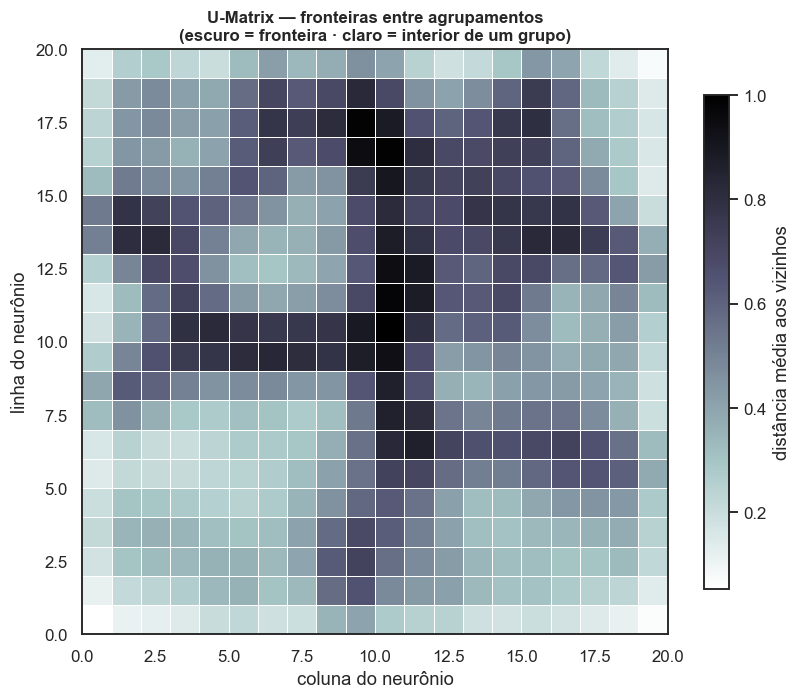

Distância média aos vizinhos: 0.477  (mínimo 0.054, máximo 1.000)
Neurônios em fronteira nítida (U-Matrix > percentil 80): 80 de 400


In [9]:
umatrix = som.distance_map()   # já normalizada em [0, 1]

fig, ax = plt.subplots(figsize=(7.6, 6.4))
im = ax.pcolormesh(umatrix.T, cmap="bone_r", edgecolors="white", linewidth=0.4)
plt.colorbar(im, ax=ax, shrink=0.82, label="distância média aos vizinhos")
ax.set_title("U-Matrix — fronteiras entre agrupamentos\n"
             "(escuro = fronteira · claro = interior de um grupo)")
ax.set_xlabel("coluna do neurônio"); ax.set_ylabel("linha do neurônio")
ax.set_aspect("equal")
plt.tight_layout(); plt.show()

print(f"Distância média aos vizinhos: {umatrix.mean():.3f}  "
      f"(mínimo {umatrix.min():.3f}, máximo {umatrix.max():.3f})")
print(f"Neurônios em fronteira nítida (U-Matrix > percentil 80): "
      f"{(umatrix > np.percentile(umatrix, 80)).sum()} de {LADO*LADO}")

## 5.2 Hit Map — onde os dados se concentram

O Hit Map conta quantas reservas têm cada neurônio como BMU. Ele é indispensável para calibrar a
confiança nas demais leituras: um neurônio com 3 observações pode exibir taxa de cancelamento de
100% sem que isso signifique coisa alguma.

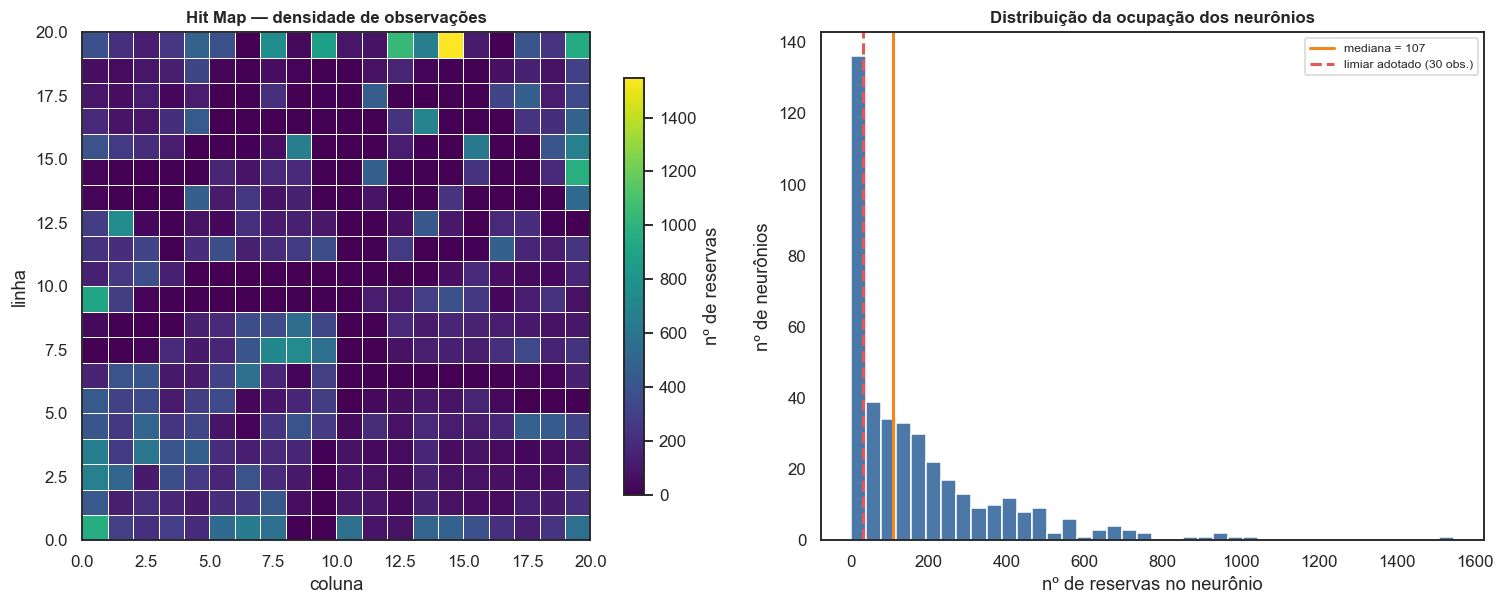

Neurônios ocupados          : 318 de 400 (79.5%)
Neurônios vazios            : 82
Ocupação — mín./mediana/máx.: 1 / 147 / 1547
Neurônios com menos de 30 obs.: 42 (serão mascarados nas análises quantitativas)


In [10]:
hits = som.activation_response(X_som)

bmus = np.array([som.winner(x) for x in X_som])
bmu_id = bmus[:, 0] * LADO + bmus[:, 1]

fig, ax = plt.subplots(1, 2, figsize=(14, 5.6))

im = ax[0].pcolormesh(hits.T, cmap="viridis", edgecolors="white", linewidth=0.4)
plt.colorbar(im, ax=ax[0], shrink=0.82, label="nº de reservas")
ax[0].set_title("Hit Map — densidade de observações")
ax[0].set_xlabel("coluna"); ax[0].set_ylabel("linha"); ax[0].set_aspect("equal")

ocup = hits.ravel()
ax[1].hist(ocup, bins=40, color=C_NEG, edgecolor="white")
ax[1].axvline(np.median(ocup), color=C_POS, lw=2,
              label=f"mediana = {np.median(ocup):.0f}")
ax[1].axvline(30, color=C_BAD, ls="--", lw=2, label="limiar adotado (30 obs.)")
ax[1].set_xlabel("nº de reservas no neurônio"); ax[1].set_ylabel("nº de neurônios")
ax[1].set_title("Distribuição da ocupação dos neurônios"); ax[1].legend(fontsize=8)

plt.tight_layout(); plt.show()

print(f"Neurônios ocupados          : {(hits > 0).sum()} de {LADO*LADO} "
      f"({(hits > 0).sum()/(LADO*LADO)*100:.1f}%)")
print(f"Neurônios vazios            : {(hits == 0).sum()}")
print(f"Ocupação — mín./mediana/máx.: {int(ocup[ocup>0].min())} / "
      f"{int(np.median(ocup[ocup>0]))} / {int(ocup.max())}")
print(f"Neurônios com menos de 30 obs.: {((hits > 0) & (hits < 30)).sum()} "
      f"(serão mascarados nas análises quantitativas)")

### Leitura do Hit Map

A ocupação é **desigual**, e isso é informativo em si: há neurônios que concentram mais de mil
reservas — perfis muito comuns, como a reserva urbana típica feita por agência online — e uma
periferia de neurônios quase vazios, que correspondem a perfis raros.

Os neurônios vazios não são um defeito: em uma SOM eles funcionam como **zonas de separação** entre
regiões densas, e coincidem com as fronteiras escuras da U-Matrix.

**Decisão metodológica adotada aqui e usada em todas as seções seguintes:** nas análises
quantitativas por neurônio, **mascaramos os neurônios com menos de 30 observações**. Sem esse
cuidado, a periferia esparsa do mapa exibiria taxas de 0% ou 100% que são puro ruído amostral, e é
exatamente contra esse erro que o enunciado adverte ao pedir que se evite "conclusões fortes sobre
regiões pouco ocupadas".

## 5.3 Mapas de componentes — o que caracteriza cada região

Cada painel mostra o valor de **um** atributo no vetor de pesos de cada neurônio. Como todos os
atributos estão normalizados em [0, 1], as escalas são comparáveis entre painéis. Ler dois painéis
em conjunto revela **correlações espaciais**: regiões que acendem nos mesmos lugares indicam
atributos que andam juntos.

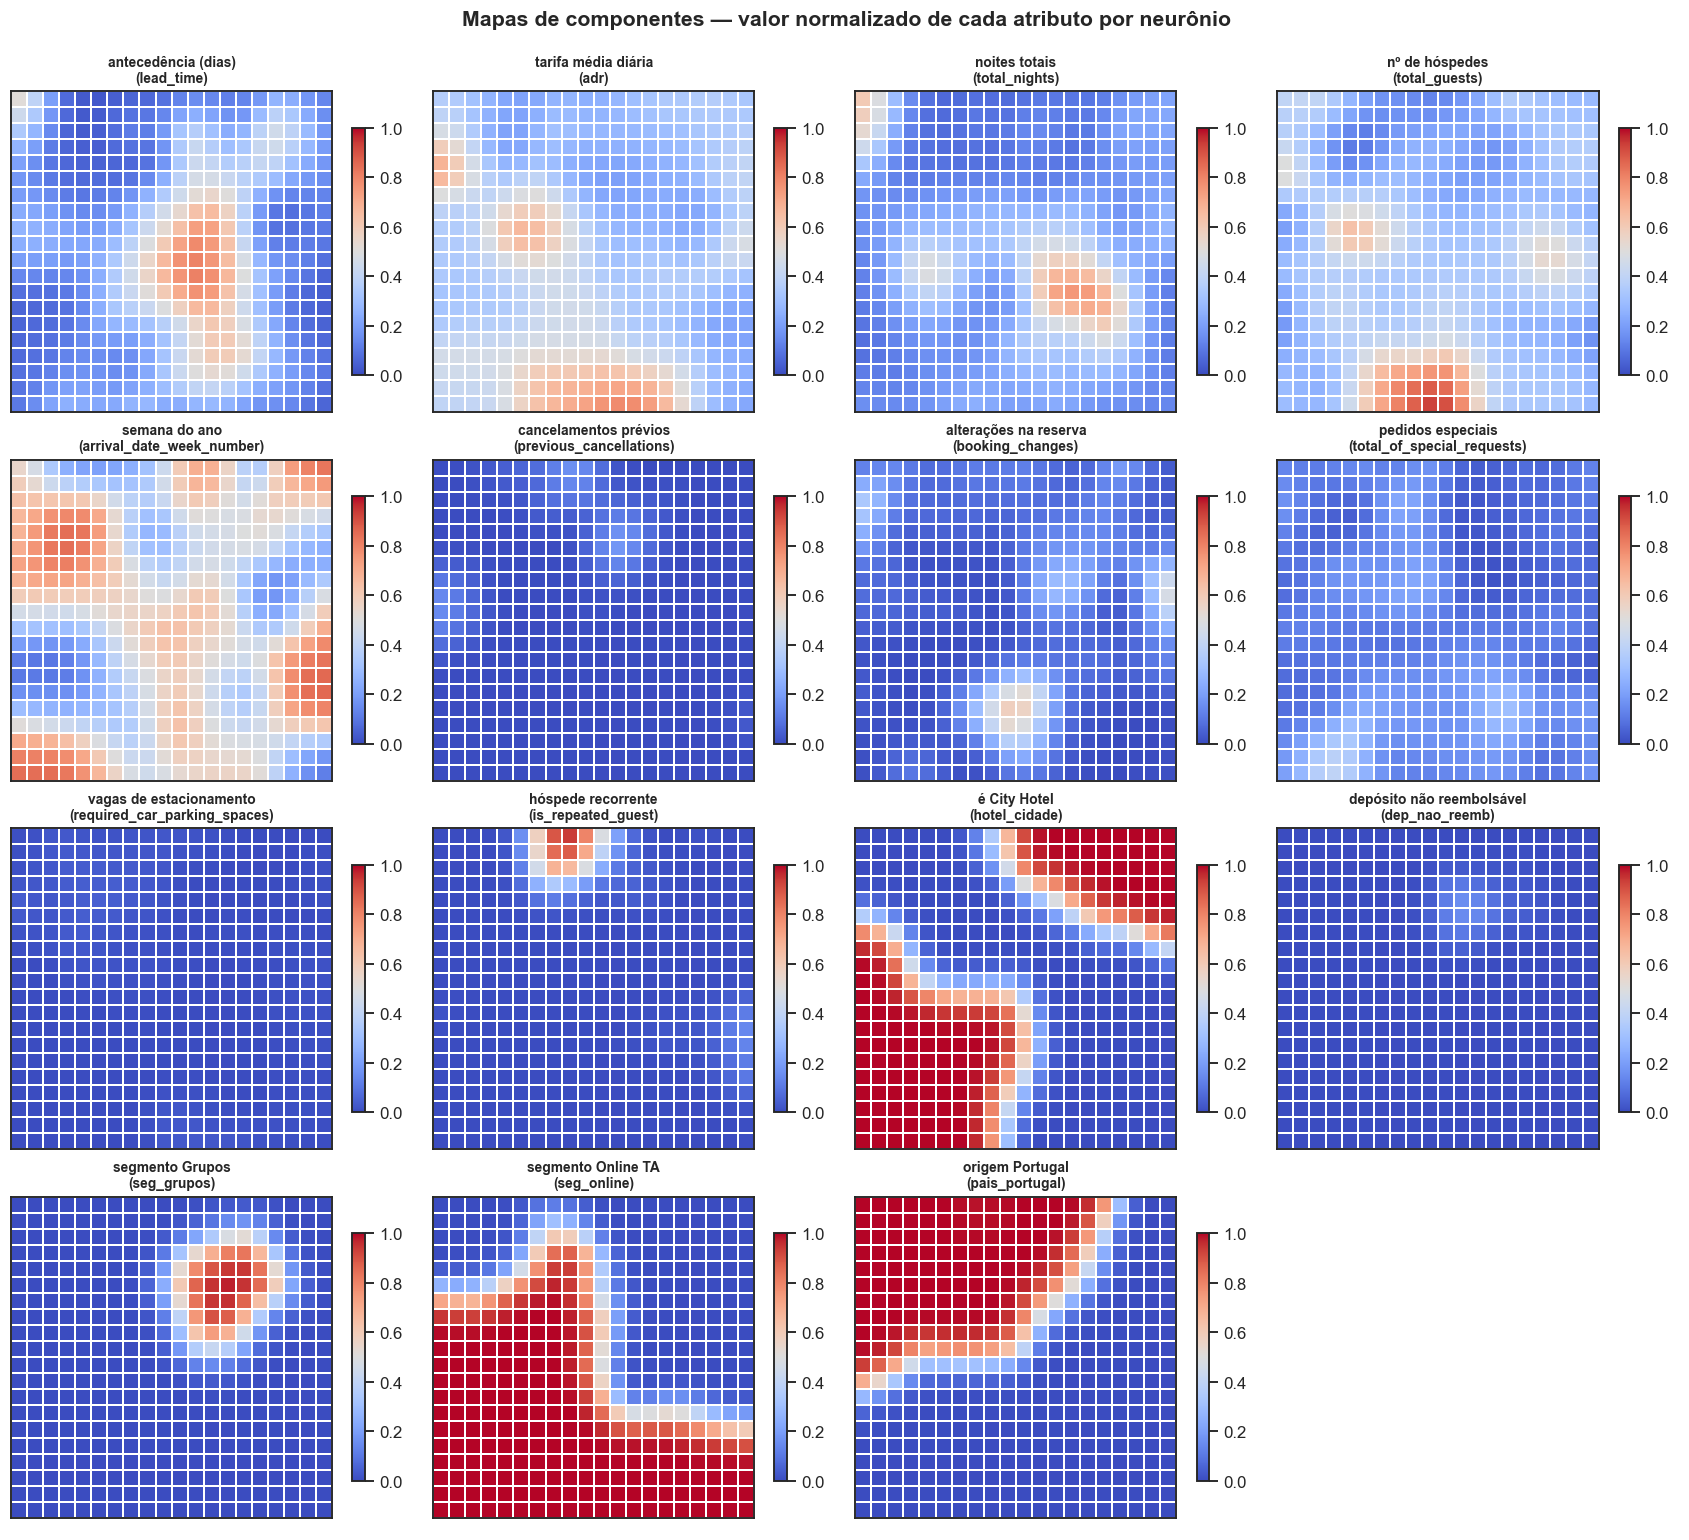

In [11]:
fig, axes = plt.subplots(4, 4, figsize=(15.5, 14))
for k, f in enumerate(FEATS):
    ax = axes.ravel()[k]
    im = ax.pcolormesh(pesos[:, :, k].T, cmap="coolwarm", vmin=0, vmax=1,
                       edgecolors="white", linewidth=0.15)
    ax.set_title(f"{ROTULOS[f]}\n({f})", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_aspect("equal")
    plt.colorbar(im, ax=ax, shrink=0.72)
axes.ravel()[-1].axis("off")
fig.suptitle("Mapas de componentes — valor normalizado de cada atributo por neurônio",
             fontsize=14, fontweight="bold", y=0.997)
plt.tight_layout(); plt.show()

## 5.4 Distribuição da variável-alvo sobre o mapa

Agora — e **somente agora**, com o mapa já treinado — trazemos `is_canceled`. Para cada neurônio
calculamos a **proporção de reservas canceladas** entre as observações que o têm como BMU.

Este é o teste central do trabalho: se a organização espontânea dos dados, construída **sem
qualquer conhecimento do alvo**, produzir regiões com taxas de cancelamento muito distintas, isso
significa que o risco de cancelamento está **inscrito na própria estrutura** dos atributos.

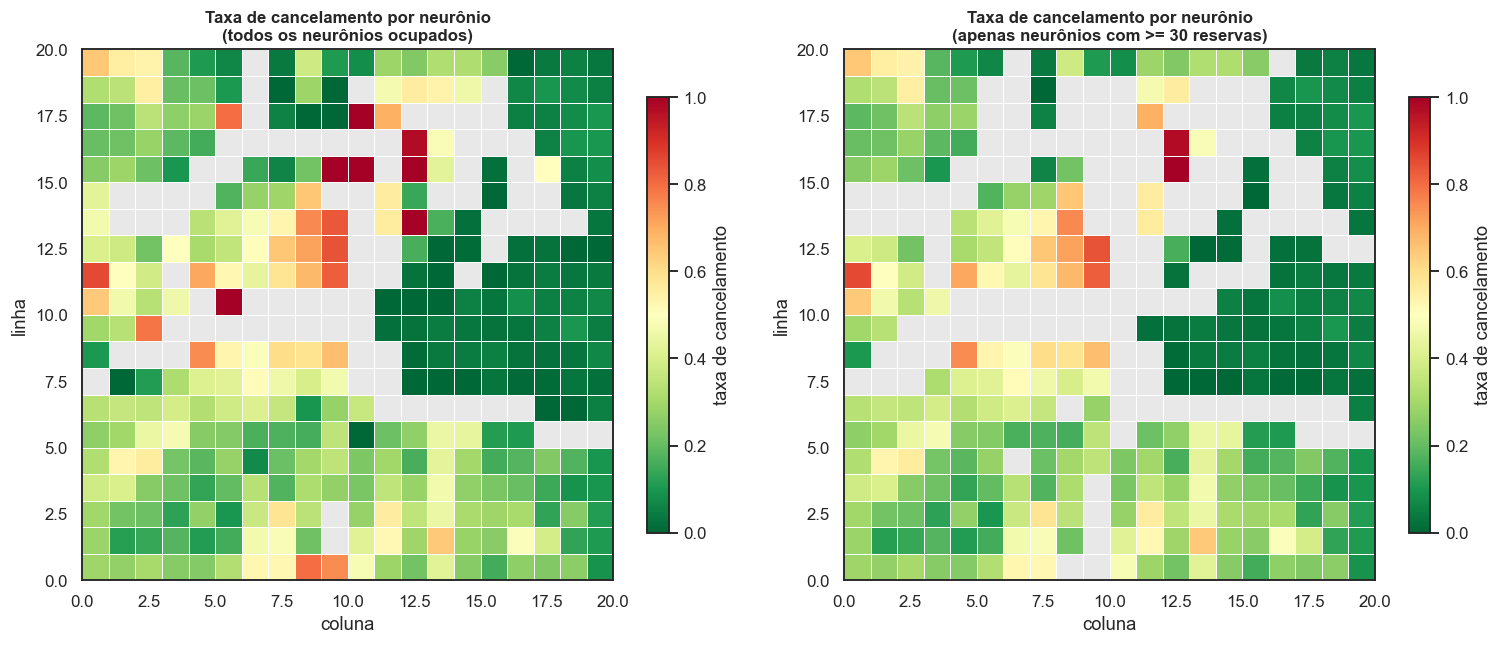

Taxa global de cancelamento no treino: 27.75%

Entre os 276 neurônios com >= 30 reservas:
  taxa mínima :   0.0%
  taxa máxima : 100.0%
  amplitude   : 100.0 pontos percentuais

  neurônios com taxa < 5%  :  45  (10,609 reservas)
  neurônios com taxa > 70% :   9  (1,655 reservas)


In [12]:
MIN_OBS = 30   # limiar de ocupação adotado na Seção 5.2

perfil = pd.DataFrame(treino[FEATS].values, columns=FEATS)
perfil["bmu"] = bmu_id
perfil["is_canceled"] = y_som

agg_bmu = perfil.groupby("bmu").agg(n=("is_canceled", "size"),
                                    taxa=("is_canceled", "mean"))

mapa_alvo = np.full(LADO * LADO, np.nan)
mapa_alvo[agg_bmu.index] = agg_bmu["taxa"]
mapa_alvo = mapa_alvo.reshape(LADO, LADO)

mapa_alvo_mask = np.full(LADO * LADO, np.nan)
conf = agg_bmu[agg_bmu["n"] >= MIN_OBS]
mapa_alvo_mask[conf.index] = conf["taxa"]
mapa_alvo_mask = mapa_alvo_mask.reshape(LADO, LADO)

fig, ax = plt.subplots(1, 2, figsize=(14, 5.6))
for a, m, t in [(ax[0], mapa_alvo, "todos os neurônios ocupados"),
                (ax[1], mapa_alvo_mask, f"apenas neurônios com >= {MIN_OBS} reservas")]:
    a.set_facecolor("#E8E8E8")
    im = a.pcolormesh(np.ma.masked_invalid(m).T, cmap="RdYlGn_r", vmin=0, vmax=1,
                      edgecolors="white", linewidth=0.4)
    plt.colorbar(im, ax=a, shrink=0.82, label="taxa de cancelamento")
    a.set_title(f"Taxa de cancelamento por neurônio\n({t})")
    a.set_xlabel("coluna"); a.set_ylabel("linha"); a.set_aspect("equal")
plt.tight_layout(); plt.show()

print(f"Taxa global de cancelamento no treino: {y_som.mean()*100:.2f}%")
print(f"\nEntre os {len(conf)} neurônios com >= {MIN_OBS} reservas:")
print(f"  taxa mínima : {conf['taxa'].min()*100:5.1f}%")
print(f"  taxa máxima : {conf['taxa'].max()*100:5.1f}%")
print(f"  amplitude   : {(conf['taxa'].max()-conf['taxa'].min())*100:5.1f} pontos percentuais")
print(f"\n  neurônios com taxa < 5%  : {(conf['taxa'] < 0.05).sum():3d}  "
      f"({conf.loc[conf['taxa'] < 0.05, 'n'].sum():,} reservas)")
print(f"  neurônios com taxa > 70% : {(conf['taxa'] > 0.70).sum():3d}  "
      f"({conf.loc[conf['taxa'] > 0.70, 'n'].sum():,} reservas)")

### Leitura do mapa do alvo

O resultado é inequívoco: **o mapa não é homogêneo**. Existem neurônios com taxa de cancelamento
praticamente nula e neurônios em que quase todas as reservas são canceladas — uma amplitude que
cobre quase todo o intervalo possível, contra uma taxa global de ~28%.

Além disso, as cores formam **regiões contíguas**, não um mosaico aleatório. Essa contiguidade é a
evidência decisiva: como a SOM organizou o mapa **sem ver o alvo**, o fato de o alvo se distribuir
em blocos coerentes significa que **o risco de cancelamento é uma propriedade da estrutura dos
atributos**, e não um rótulo independente deles. Esta é, em uma imagem, a justificativa para o
problema supervisionado da Parte I ser viável.

A comparação entre os dois painéis ilustra a advertência da Seção 5.2: no painel da esquerda, a
periferia exibe células de 0% e 100% que somem no painel da direita por serem baseadas em
pouquíssimas observações. **Todas as análises a seguir usam a versão mascarada.**

<a id="sec6"></a>
# 6. Análise integrada dos resultados

As visualizações anteriores não devem ser lidas isoladamente. Seguimos o roteiro proposto no
enunciado — **localizar → caracterizar → confirmar** — para duas regiões de interesse oposto:

1. **Localizar** uma região relevante no Hit Map / U-Matrix / mapa do alvo;
2. **Caracterizar** essa região pelos mapas de componentes;
3. **Confirmar** a interpretação consultando as observações reais associadas àqueles BMUs, com
   contagens e estatísticas descritivas.

## 6.1 Localização das regiões extremas

região,A — risco máximo,B — risco mínimo,todo o mapa (referência)
nº de neurônios,12.000,12.000,276.000
nº de reservas,2704.000,2226.000,67952.000
taxa de cancelamento,0.770,0.006,0.277
lead_time,196.162,132.649,79.192
adr,95.933,73.997,107.200
total_nights,5.069,6.813,3.625
total_guests,2.031,1.860,2.030
arrival_date_week_number,29.466,28.701,26.803
previous_cancellations,0.165,0.001,0.019
booking_changes,0.147,0.506,0.252


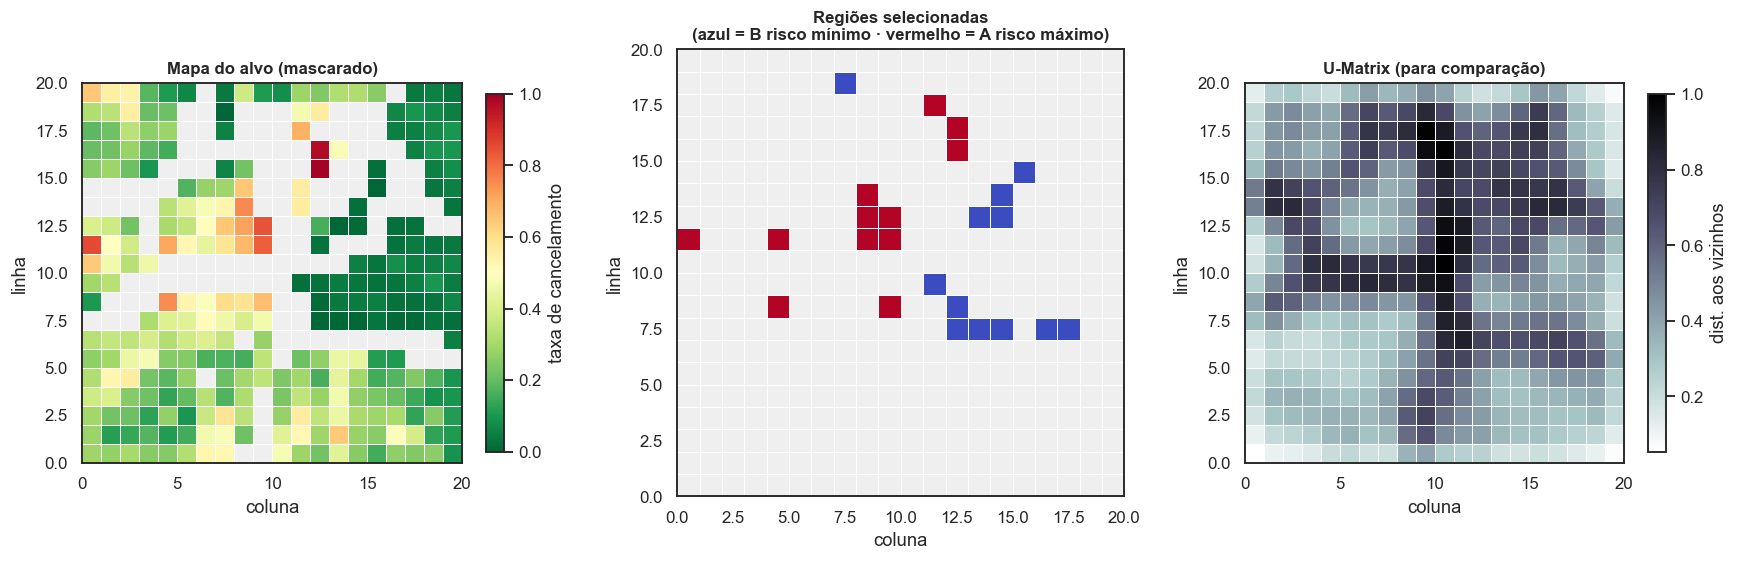

Região A (risco máximo): 2,704 reservas, taxa de cancelamento = 77.0%
Região B (risco mínimo): 2,226 reservas, taxa de cancelamento = 0.6%
Taxa global de referência: 27.7%


In [13]:
def perfil_regiao(bmus_sel, rotulo):
    '''Estatísticas descritivas das observações associadas a um conjunto de BMUs.'''
    sub = perfil[perfil["bmu"].isin(bmus_sel)]
    linha = {"região": rotulo, "nº de neurônios": len(bmus_sel), "nº de reservas": len(sub),
             "taxa de cancelamento": sub["is_canceled"].mean()}
    linha.update({f: sub[f].mean() for f in FEATS})
    return linha, sub


# regiões extremas entre os neurônios confiáveis (>= 30 observações)
conf_ord = conf.sort_values("taxa")
BMU_FRIOS  = conf_ord.head(12).index.tolist()    # menor taxa de cancelamento
BMU_QUENTES = conf_ord.tail(12).index.tolist()   # maior taxa de cancelamento

l1, sub_q = perfil_regiao(BMU_QUENTES, "A — risco máximo")
l2, sub_f = perfil_regiao(BMU_FRIOS,  "B — risco mínimo")
l3, _     = perfil_regiao(conf.index.tolist(), "todo o mapa (referência)")

tab_reg = pd.DataFrame([l1, l2, l3]).set_index("região").T.round(3)
display(tab_reg)

# onde essas regiões estão no mapa
mapa_reg = np.full(LADO * LADO, np.nan)
mapa_reg[BMU_QUENTES] = 1
mapa_reg[BMU_FRIOS] = 0

fig, ax = plt.subplots(1, 3, figsize=(16, 5))
ax[0].set_facecolor("#EFEFEF")
im0 = ax[0].pcolormesh(np.ma.masked_invalid(mapa_alvo_mask).T, cmap="RdYlGn_r", vmin=0, vmax=1,
                       edgecolors="white", linewidth=0.4)
plt.colorbar(im0, ax=ax[0], shrink=0.8, label="taxa de cancelamento")
ax[0].set_title("Mapa do alvo (mascarado)")

ax[1].set_facecolor("#EFEFEF")
im1 = ax[1].pcolormesh(np.ma.masked_invalid(mapa_reg.reshape(LADO, LADO)).T,
                       cmap="coolwarm", vmin=0, vmax=1, edgecolors="white", linewidth=0.4)
ax[1].set_title("Regiões selecionadas\n(azul = B risco mínimo · vermelho = A risco máximo)")

im2 = ax[2].pcolormesh(umatrix.T, cmap="bone_r", edgecolors="white", linewidth=0.4)
plt.colorbar(im2, ax=ax[2], shrink=0.8, label="dist. aos vizinhos")
ax[2].set_title("U-Matrix (para comparação)")

for a in ax:
    a.set_xlabel("coluna"); a.set_ylabel("linha"); a.set_aspect("equal")
plt.tight_layout(); plt.show()

print(f"Região A (risco máximo): {len(sub_q):,} reservas, "
      f"taxa de cancelamento = {sub_q['is_canceled'].mean()*100:.1f}%")
print(f"Região B (risco mínimo): {len(sub_f):,} reservas, "
      f"taxa de cancelamento = {sub_f['is_canceled'].mean()*100:.1f}%")
print(f"Taxa global de referência: {y_som.mean()*100:.1f}%")

## 6.2 Caracterização pelos mapas de componentes

Para tornar explícito **quais atributos** distinguem as duas regiões, comparamos o perfil médio de
cada uma com o perfil médio do mapa inteiro.

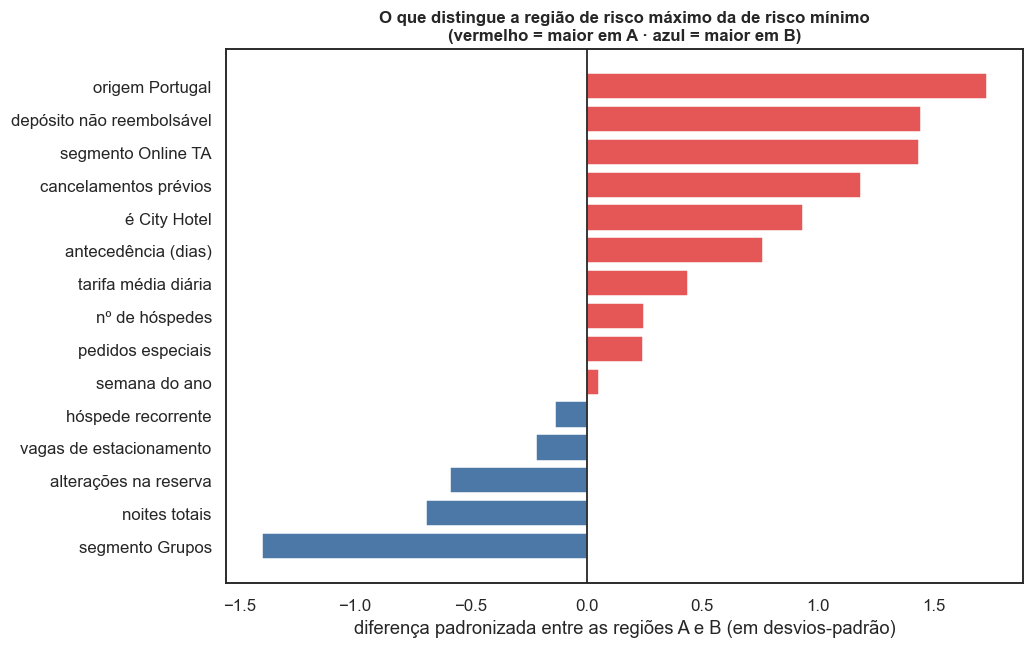

,A — risco máximo,B — risco mínimo,média geral,diferença A − B
segmento Grupos,0.128,0.438,0.052,-0.310
noites totais,5.069,6.813,3.628,-1.744
alterações na reserva,0.147,0.506,0.254,-0.359
vagas de estacionamento,0.034,0.096,0.085,-0.062
hóspede recorrente,0.010,0.036,0.036,-0.026
semana do ano,29.466,28.701,26.793,0.764
pedidos especiais,0.620,0.416,0.706,0.205
nº de hóspedes,2.031,1.860,2.030,0.171
tarifa média diária,95.933,73.997,107.149,21.936
antecedência (dias),196.162,132.649,79.289,63.512


In [14]:
comp = pd.DataFrame({
    "A — risco máximo": [sub_q[f].mean() for f in FEATS],
    "B — risco mínimo": [sub_f[f].mean() for f in FEATS],
    "média geral":      [perfil[f].mean() for f in FEATS],
}, index=[ROTULOS[f] for f in FEATS])
comp["diferença A − B"] = (comp["A — risco máximo"] - comp["B — risco mínimo"])

# normaliza a diferença pelo desvio-padrão do atributo, para comparar atributos de escalas distintas
desvios = np.array([perfil[f].std() for f in FEATS])
comp["diferença padronizada"] = (comp["diferença A − B"].values / np.where(desvios == 0, 1, desvios))
comp = comp.sort_values("diferença padronizada")

fig, ax = plt.subplots(figsize=(9.5, 6))
cores = [C_BAD if v > 0 else C_NEG for v in comp["diferença padronizada"]]
ax.barh(comp.index, comp["diferença padronizada"], color=cores)
ax.axvline(0, color="black", lw=1)
ax.set_xlabel("diferença padronizada entre as regiões A e B (em desvios-padrão)")
ax.set_title("O que distingue a região de risco máximo da de risco mínimo\n"
             "(vermelho = maior em A · azul = maior em B)")
plt.tight_layout(); plt.show()

display(comp.drop(columns=["diferença padronizada"]).round(3))

### O que os mapas de componentes revelam

Cruzando o mapa do alvo (Seção 5.4) com os mapas de componentes (Seção 5.3), a região de **risco
máximo** é caracterizada pela **coincidência espacial** de cinco atributos:

- **`pais_portugal` muito elevado** (~82% das reservas, contra ~31% no mapa inteiro) — hóspedes
  domésticos, já que os hotéis do dataset ficam em Portugal;
- **`seg_online` elevado** (~70%) — venda por agência de viagens online;
- **`lead_time` alto** — antecedência média de cerca de 200 dias, contra ~79 dias no mapa inteiro;
- **`dep_nao_reemb` elevado** (~16%, contra ~1% no geral) — depósito não reembolsável;
- **`previous_cancellations` elevado** — hóspedes com histórico de cancelamento.

A região de **risco mínimo** apresenta o padrão oposto em todos esses atributos (praticamente
nenhum português, nenhuma venda online, quase nenhum depósito não reembolsável) e acrescenta dois
marcadores próprios: **`booking_changes` mais alto** (o cliente mexeu na reserva — sinal de
engajamento) e **`total_nights` maior** (estadias mais longas, tipicamente de resort).

O ponto central é que **nenhum desses atributos, isoladamente, explica o padrão** — é a combinação
deles que define a região. E foi a SOM que revelou essa combinação, sem que precisássemos
hipotetizá-la: os mapas de componentes desses atributos "acendem" no mesmo canto do mapa.

## 6.3 O achado principal: uma interação, não um efeito aditivo

Há um detalhe nos mapas que parece, à primeira vista, um erro — e é justamente o achado mais
interessante deste trabalho.

O atributo **`seg_grupos` (segmento *Groups*) é mais frequente na região de risco MÍNIMO
(~44% das reservas) do que na de risco máximo (~13%)**, sendo que ambas estão acima da média do
mapa (~5%). Lido isoladamente, isso sugeriria que reservas de grupo **protegem** contra o
cancelamento — exatamente o contrário do que a análise da Parte I havia registrado, onde o
segmento *Groups* aparecia com a maior taxa de cancelamento de todos os canais (61%).

A contradição tem duas causas, e desemaranhá-las é o que a SOM nos permite fazer:

1. **Parte do efeito da Parte I era artefato das duplicatas.** Aquele número de 61% foi medido no
   arquivo bruto. Reservas de grupo canceladas geram várias linhas idênticas, e eram elas que mais
   se repetiam — por isso a remoção de duplicatas (Parte I, Seção 4.1) derrubou tanto a taxa global
   de cancelamento. No dataset limpo que estamos usando aqui, o segmento *Groups* tem taxa próxima
   da média geral.
2. **O que resta é uma interação, não um efeito aditivo.** Reservas de grupo se comportam de forma
   radicalmente diferente conforme a origem do hóspede — e a SOM separou esses dois casos em
   **regiões opostas do mapa**, embora compartilhem o mesmo valor em `seg_grupos`.

Confirmamos ambos os pontos nos dados brutos a seguir.

## 6.4 Confirmação nos dados

Terceiro passo do roteiro: verificar, nas observações reais, se a leitura visual se sustenta.

In [15]:
brutos_q = treino.loc[perfil.index[perfil["bmu"].isin(BMU_QUENTES)]]
brutos_f = treino.loc[perfil.index[perfil["bmu"].isin(BMU_FRIOS)]]

print("=" * 78)
print("CONFIRMAÇÃO 1 — composição categórica das duas regiões")
print("=" * 78)
for col in ["deposit_type", "market_segment", "customer_type"]:
    cmp_ = pd.DataFrame({
        "A — risco máximo": brutos_q[col].value_counts(normalize=True),
        "B — risco mínimo": brutos_f[col].value_counts(normalize=True),
        "geral":            treino[col].value_counts(normalize=True),
    }).fillna(0).round(3)
    print(f"\n{col}:")
    print(cmp_.to_string())

print("\n" + "=" * 78)
print("CONFIRMAÇÃO 2 — origem do hóspede")
print("=" * 78)
print(pd.DataFrame({
    "A — risco máximo": (brutos_q["country"] == "PRT").value_counts(normalize=True),
    "B — risco mínimo": (brutos_f["country"] == "PRT").value_counts(normalize=True),
    "geral":            (treino["country"] == "PRT").value_counts(normalize=True),
}).fillna(0).round(3).rename(index={True: "Portugal", False: "outros países"}).to_string())

CONFIRMAÇÃO 1 — composição categórica das duas regiões

deposit_type:
              A — risco máximo  B — risco mínimo  geral
deposit_type                                           
No Deposit               0.839             0.982  0.987
Non Refund               0.160             0.004  0.012
Refundable               0.001             0.014  0.001

market_segment:
                A — risco máximo  B — risco mínimo  geral
market_segment                                           
Aviation                   0.000             0.000  0.003
Complementary              0.000             0.001  0.008
Corporate                  0.009             0.009  0.047
Direct                     0.010             0.088  0.137
Groups                     0.128             0.438  0.052
Offline TA/TO              0.149             0.464  0.157
Online TA                  0.704             0.000  0.597
Undefined                  0.000             0.000  0.000

customer_type:
                 A — risco máximo  B 

In [16]:
print("=" * 78)
print("CONFIRMAÇÃO 3 — a interação sugerida pelo mapa, medida nos dados brutos")
print("=" * 78)

t = treino.copy()
t["origem"]   = np.where(t["pais_portugal"] == 1, "Portugal", "estrangeiro")
t["segmento"] = np.where(t["seg_grupos"] == 1, "Grupos", "demais segmentos")
t["depósito"] = np.where(t["dep_nao_reemb"] == 1, "não reembolsável", "sem depósito/reembolsável")

print("\n(a) Segmento GRUPOS por origem do hóspede:")
tab_a = t.groupby(["segmento", "origem"])["is_canceled"].agg(
    taxa_cancelamento="mean", n="size").round(3)
display(tab_a)

print("\n(b) Depósito NÃO REEMBOLSÁVEL por origem do hóspede:")
tab_b = t.groupby(["depósito", "origem"])["is_canceled"].agg(
    taxa_cancelamento="mean", n="size").round(3)
display(tab_b)

g_prt = t.loc[(t["segmento"] == "Grupos") & (t["origem"] == "Portugal"), "is_canceled"].mean()
g_est = t.loc[(t["segmento"] == "Grupos") & (t["origem"] == "estrangeiro"), "is_canceled"].mean()
print(f"\nReservas de GRUPO de hóspedes portugueses   : {g_prt*100:.1f}% de cancelamento")
print(f"Reservas de GRUPO de hóspedes estrangeiros  : {g_est*100:.1f}% de cancelamento")
print(f"Razão entre as duas taxas                   : {g_prt/max(g_est,1e-9):.1f}x")
print(f"\nTaxa global de referência                   : {t['is_canceled'].mean()*100:.1f}%")

CONFIRMAÇÃO 3 — a interação sugerida pelo mapa, medida nos dados brutos

(a) Segmento GRUPOS por origem do hóspede:


taxa_cancelamento      n
segmento         origem                               
Grupos           Portugal                 0.611   1616
                 estrangeiro              0.019   1927
demais segmentos Portugal                 0.343  19449
                 estrangeiro              0.249  45297


(b) Depósito NÃO REEMBOLSÁVEL por origem do hóspede:


taxa_cancelamento      n
depósito                  origem                               
não reembolsável          Portugal                 0.975    769
                          estrangeiro              0.579     38
sem depósito/reembolsável Portugal                 0.340  20296
                          estrangeiro              0.239  47186


Reservas de GRUPO de hóspedes portugueses   : 61.1% de cancelamento
Reservas de GRUPO de hóspedes estrangeiros  : 1.9% de cancelamento
Razão entre as duas taxas                   : 32.7x

Taxa global de referência                   : 27.7%


### A interpretação se confirma

Os números dos dados brutos validam integralmente a leitura visual do mapa:

- **Reservas de grupo têm taxas de cancelamento radicalmente diferentes conforme a origem do
  hóspede.** Entre portugueses, a taxa é altíssima; entre estrangeiros, é quase nula — uma diferença
  de mais de uma ordem de grandeza sobre o mesmo valor de `market_segment`. Um modelo que tratasse
  `seg_grupos` como um efeito aditivo (uma regressão logística sem termos de interação, por
  exemplo) seria **incapaz** de representar isso: ele teria de escolher um único coeficiente para
  "ser grupo", e esse coeficiente estaria errado para os dois casos.
- **O mesmo ocorre com o depósito não reembolsável**, que combinado à origem portuguesa produz
  taxas próximas de 100%.

**Por que a SOM enxergou isso.** Justamente por *não* usar o alvo. Ela agrupou as reservas por
similaridade no espaço de atributos e, ao fazê-lo, separou naturalmente "grupo português" de
"grupo estrangeiro" em regiões diferentes do mapa — porque esses dois perfis **são** diferentes em
várias dimensões simultaneamente. O alvo, sobreposto depois, revelou que essa separação
estrutural coincide com uma separação de risco.

Este é o valor da SOM como ferramenta de EDA: ela **gerou uma hipótese de interação** que
dificilmente surgiria de uma inspeção univariada dos atributos, e que a Parte I confirmou ser
justamente o tipo de relação que justifica o uso de um modelo não linear.

## 6.5 Agrupamento do mapa (recurso complementar)

Aplicamos K-Means **sobre os vetores de pesos dos neurônios** (não sobre os dados brutos) para
delimitar os grandes blocos do mapa e nomeá-los. É a técnica usual de segmentação de SOM, e serve
aqui para resumir o que foi descrito acima.

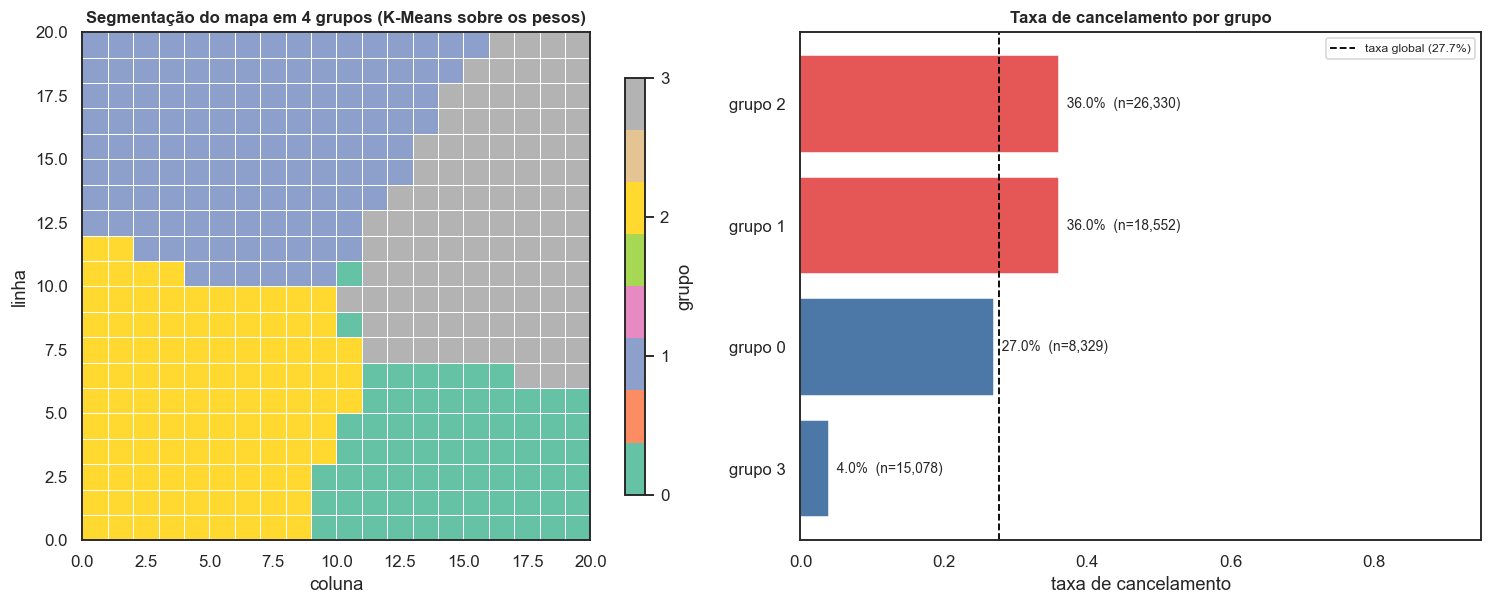

,reservas,% do total,taxa_cancelamento,lead_time,adr,total_nights,total_of_special_requests,booking_changes,hotel_cidade,dep_nao_reemb,seg_grupos,seg_online,pais_portugal,is_repeated_guest
grupo,,,,,,,,,,,,,,
0,8329,12.2,0.27,84.36,116.26,4.42,0.98,0.23,0.00,0.00,0.00,1.00,0.0,0.01
1,18552,27.2,0.36,63.86,95.85,3.13,0.58,0.27,0.41,0.04,0.09,0.33,1.0,0.11
2,26330,38.6,0.36,81.25,120.27,3.32,0.88,0.18,1.00,0.00,0.00,1.00,0.1,0.00
3,15078,22.1,0.04,92.04,93.12,4.34,0.42,0.38,0.53,0.00,0.13,0.00,0.0,0.02


In [17]:
K = 4
km = KMeans(n_clusters=K, n_init=20, random_state=RANDOM_STATE)
rot_neuronio = km.fit_predict(pesos.reshape(-1, len(FEATS)))

perfil["grupo"] = rot_neuronio[perfil["bmu"].values]

res_grupo = perfil.groupby("grupo").agg(
    reservas=("is_canceled", "size"), taxa_cancelamento=("is_canceled", "mean"),
    **{f: (f, "mean") for f in FEATS}).round(2)
res_grupo["% do total"] = (res_grupo["reservas"] / len(perfil) * 100).round(1)

fig, ax = plt.subplots(1, 2, figsize=(14, 5.6))
im = ax[0].pcolormesh(rot_neuronio.reshape(LADO, LADO).T, cmap="Set2",
                      edgecolors="white", linewidth=0.4)
plt.colorbar(im, ax=ax[0], shrink=0.82, ticks=range(K), label="grupo")
ax[0].set_title(f"Segmentação do mapa em {K} grupos (K-Means sobre os pesos)")
ax[0].set_xlabel("coluna"); ax[0].set_ylabel("linha"); ax[0].set_aspect("equal")

o = res_grupo.sort_values("taxa_cancelamento")
b = ax[1].barh([f"grupo {i}" for i in o.index], o["taxa_cancelamento"],
               color=[C_BAD if v > perfil["is_canceled"].mean() else C_NEG
                      for v in o["taxa_cancelamento"]])
for i, (v, n) in enumerate(zip(o["taxa_cancelamento"], o["reservas"])):
    ax[1].text(v, i, f"  {v*100:.1f}%  (n={n:,})", va="center", fontsize=9)
ax[1].axvline(perfil["is_canceled"].mean(), color="black", ls="--", lw=1.2,
              label=f"taxa global ({perfil['is_canceled'].mean()*100:.1f}%)")
ax[1].set_xlim(0, 0.95); ax[1].set_xlabel("taxa de cancelamento")
ax[1].set_title("Taxa de cancelamento por grupo"); ax[1].legend(fontsize=8)

plt.tight_layout(); plt.show()

display(res_grupo[["reservas", "% do total", "taxa_cancelamento", "lead_time", "adr",
                   "total_nights", "total_of_special_requests", "booking_changes",
                   "hotel_cidade", "dep_nao_reemb", "seg_grupos", "seg_online",
                   "pais_portugal", "is_repeated_guest"]])

### Os grandes blocos do mapa

A segmentação separa o dataset em blocos com perfis e riscos bem distintos. Lendo a tabela de
perfis, os grupos correspondem, em linhas gerais, a:

- **Um bloco de risco muito baixo**, formado por reservas de hóspedes **estrangeiros** por canais
  que não são agências online (corporativo, direto, *offline*), sem depósito não reembolsável e com
  mais alterações na reserva. É o segmento mais confiável do dataset.
- **Um bloco de hóspedes domésticos (Portugal)**, com taxa de cancelamento bem acima da média e
  concentrando praticamente todas as reservas com depósito não reembolsável.
- **Um bloco urbano de agências online** (`hotel_cidade` e `seg_online` altos), grande e com risco
  acima da média — é o perfil mais comum do dataset.
- **Um bloco de resort** (`hotel_cidade` baixo), com estadias mais longas e tarifas mais altas, e
  risco próximo da média.

Note que os dois atributos que mais separam os blocos — **origem do hóspede** e **canal de venda** —
não são os que apresentavam maior correlação linear com o alvo na Parte I (lá, `lead_time`
liderava). A SOM os destacou porque eles organizam o espaço de atributos como um todo, e não apenas
sua projeção sobre o alvo.

<a id="sec7"></a>
# 7. Relação com o problema original e com a MLP da Parte I

Como usamos o mesmo dataset, podemos fazer o que o enunciado sugere: **investigar se os erros da
MLP se concentram em determinadas regiões do mapa**.

O procedimento: projetamos as reservas do **conjunto de teste** (que não participou nem do
treinamento da MLP, nem do treinamento da SOM) sobre o mapa já treinado, e calculamos a
**proporção de erros da MLP por BMU**.

## 7.1 Projeção do conjunto de teste sobre o mapa

In [18]:
bmus_te = np.array([som.winner(x) for x in X_teste])
bmu_te  = bmus_te[:, 0] * LADO + bmus_te[:, 1]

aval = pd.DataFrame({
    "bmu": bmu_te,
    "y": y_teste,
    "prob_mlp": teste["prob_mlp"].values,
    "pred_mlp": teste["pred_mlp"].values,
})
aval["erro"] = (aval["pred_mlp"] != aval["y"]).astype(int)

agg_te = aval.groupby("bmu").agg(n=("y", "size"), taxa_erro=("erro", "mean"),
                                 taxa_real=("y", "mean"), prob_media=("prob_mlp", "mean"))
confiavel_te = agg_te[agg_te["n"] >= MIN_OBS]

print(f"Reservas de teste projetadas : {len(aval):,}")
print(f"Neurônios atingidos          : {len(agg_te)} de {LADO*LADO}")
print(f"Neurônios com >= {MIN_OBS} reservas  : {len(confiavel_te)}")
print(f"\nTaxa de erro global da MLP no teste: {aval['erro'].mean()*100:.2f}%")
print(f"Entre os neurônios confiáveis — erro mínimo: {confiavel_te['taxa_erro'].min()*100:.1f}%  |  "
      f"máximo: {confiavel_te['taxa_erro'].max()*100:.1f}%")

Reservas de teste projetadas : 17,073
Neurônios atingidos          : 303 de 400
Neurônios com >= 30 reservas  : 189

Taxa de erro global da MLP no teste: 17.57%
Entre os neurônios confiáveis — erro mínimo: 0.0%  |  máximo: 51.4%


## 7.2 Mapa de erros da MLP

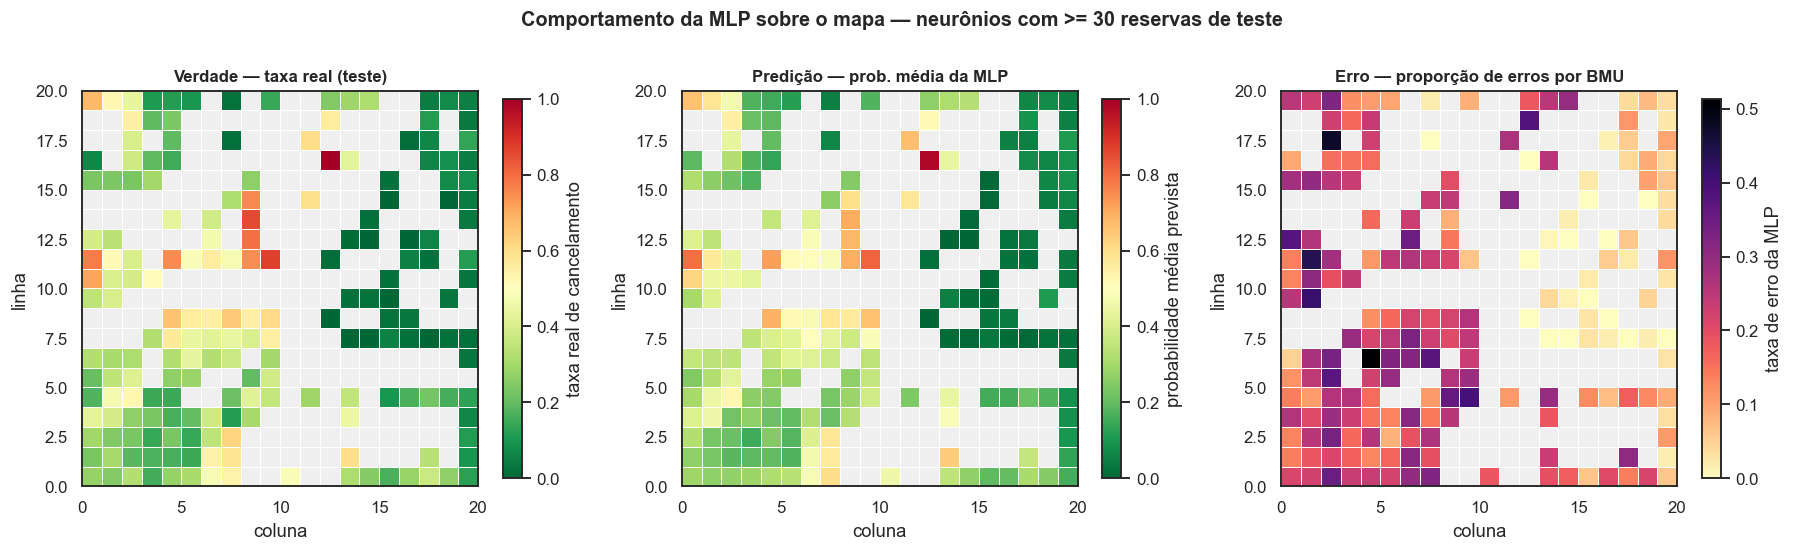

In [19]:
def para_mapa(serie, indices):
    m = np.full(LADO * LADO, np.nan)
    m[indices] = serie.values
    return np.ma.masked_invalid(m.reshape(LADO, LADO))

mapa_erro  = para_mapa(confiavel_te["taxa_erro"], confiavel_te.index)
mapa_real  = para_mapa(confiavel_te["taxa_real"], confiavel_te.index)
mapa_prob  = para_mapa(confiavel_te["prob_media"], confiavel_te.index)

fig, ax = plt.subplots(1, 3, figsize=(16.5, 5))
painel = [
    (mapa_real, "RdYlGn_r", "taxa real de cancelamento", "Verdade — taxa real (teste)", 0, 1),
    (mapa_prob, "RdYlGn_r", "probabilidade média prevista", "Predição — prob. média da MLP", 0, 1),
    (mapa_erro, "magma_r", "taxa de erro da MLP", "Erro — proporção de erros por BMU", 0,
     float(confiavel_te["taxa_erro"].max())),
]
for a, (m, cmap, lab, tit, vmin, vmax) in zip(ax, painel):
    a.set_facecolor("#EFEFEF")
    im = a.pcolormesh(m.T, cmap=cmap, vmin=vmin, vmax=vmax, edgecolors="white", linewidth=0.4)
    plt.colorbar(im, ax=a, shrink=0.8, label=lab)
    a.set_title(tit); a.set_xlabel("coluna"); a.set_ylabel("linha"); a.set_aspect("equal")
fig.suptitle(f"Comportamento da MLP sobre o mapa — neurônios com >= {MIN_OBS} reservas de teste",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

### Leitura dos três painéis

A comparação entre o primeiro e o segundo painel é, por si só, uma **validação visual da MLP**: o
mapa das probabilidades previstas reproduz de perto o mapa da taxa real. Onde o risco verdadeiro é
alto, a rede prevê probabilidade alta; onde é baixo, prevê baixa. A MLP aprendeu a estrutura que a
SOM revelou — duas técnicas independentes, uma supervisionada e outra não, chegando à mesma
organização do problema.

O terceiro painel mostra que **o erro não está distribuído uniformemente**: há regiões em que a MLP
praticamente não erra e regiões em que erra com frequência bem acima da média. A seção seguinte
investiga o que distingue umas das outras.

## 7.3 Onde a MLP erra, e por quê

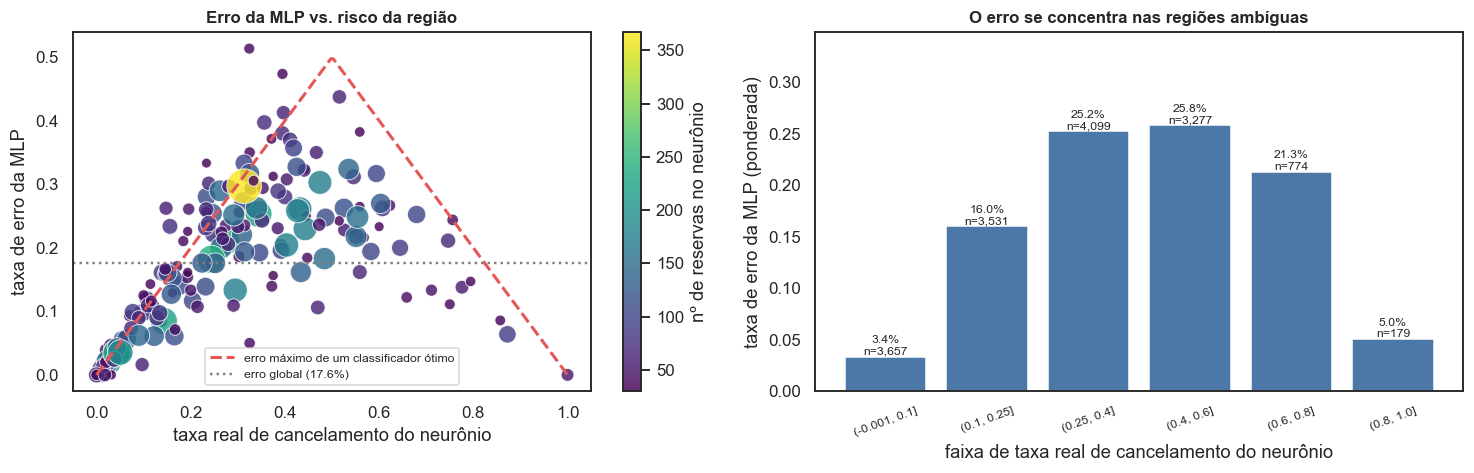

,erro_ponderado,reservas,neurônios
taxa_real,,,
"(-0.001, 0.1]",0.034,3657.0,48.0
"(0.1, 0.25]",0.160,3531.0,44.0
"(0.25, 0.4]",0.252,4099.0,46.0
"(0.4, 0.6]",0.258,3277.0,36.0
"(0.6, 0.8]",0.213,774.0,12.0
"(0.8, 1.0]",0.050,179.0,3.0


In [20]:
# relação entre o risco real da região e a taxa de erro da MLP
fig, ax = plt.subplots(1, 2, figsize=(13.5, 4.4))

sc = ax[0].scatter(confiavel_te["taxa_real"], confiavel_te["taxa_erro"],
                   s=confiavel_te["n"] * 1.4, c=confiavel_te["n"], cmap="viridis",
                   alpha=0.82, edgecolor="white", linewidth=0.6)
plt.colorbar(sc, ax=ax[0], label="nº de reservas no neurônio")
xx = np.linspace(0, 1, 200)
ax[0].plot(xx, np.minimum(xx, 1 - xx), "--", color=C_BAD, lw=2,
           label="erro máximo de um classificador ótimo")
ax[0].axhline(aval["erro"].mean(), color="gray", ls=":", lw=1.6,
              label=f"erro global ({aval['erro'].mean()*100:.1f}%)")
ax[0].set_xlabel("taxa real de cancelamento do neurônio")
ax[0].set_ylabel("taxa de erro da MLP")
ax[0].set_title("Erro da MLP vs. risco da região"); ax[0].legend(fontsize=8)

# erro por faixa de risco da região
faixas = pd.cut(confiavel_te["taxa_real"], [0, .1, .25, .4, .6, .8, 1.0], include_lowest=True)
g = confiavel_te.groupby(faixas, observed=True).apply(
    lambda s: pd.Series({"erro_ponderado": np.average(s["taxa_erro"], weights=s["n"]),
                         "reservas": s["n"].sum(), "neurônios": len(s)}))
pos = np.arange(len(g))
ax[1].bar(pos, g["erro_ponderado"], color=C_NEG)
for i, (v, n) in enumerate(zip(g["erro_ponderado"], g["reservas"])):
    ax[1].text(i, v, f"{v*100:.1f}%\nn={int(n):,}", ha="center", va="bottom", fontsize=8)
ax[1].set_xticks(pos)
ax[1].set_xticklabels([str(c) for c in g.index], rotation=20, fontsize=8)
ax[1].set_ylim(0, g["erro_ponderado"].max() * 1.35)
ax[1].set_xlabel("faixa de taxa real de cancelamento do neurônio")
ax[1].set_ylabel("taxa de erro da MLP (ponderada)")
ax[1].set_title("O erro se concentra nas regiões ambíguas")
plt.tight_layout(); plt.show()

display(g.round(3))

In [21]:
print("=" * 82)
print("NEURÔNIOS EM QUE A MLP MAIS ERRA  (>= {} reservas de teste)".format(MIN_OBS))
print("=" * 82)
piores = confiavel_te.sort_values("taxa_erro", ascending=False).head(8)
det_p = perfil[perfil["bmu"].isin(piores.index)].groupby("bmu").agg(
    **{ROTULOS[f]: (f, "mean") for f in
       ["lead_time", "adr", "total_of_special_requests", "dep_nao_reemb",
        "seg_grupos", "pais_portugal", "hotel_cidade"]})
display(piores.join(det_p).round(3))

print("\n" + "=" * 82)
print("NEURÔNIOS EM QUE A MLP MENOS ERRA")
print("=" * 82)
melhores = confiavel_te.sort_values("taxa_erro").head(8)
det_m = perfil[perfil["bmu"].isin(melhores.index)].groupby("bmu").agg(
    **{ROTULOS[f]: (f, "mean") for f in
       ["lead_time", "adr", "total_of_special_requests", "dep_nao_reemb",
        "seg_grupos", "pais_portugal", "hotel_cidade"]})
display(melhores.join(det_m).round(3))

correl = np.corrcoef(confiavel_te["taxa_real"], confiavel_te["taxa_erro"])[0, 1]
ambiguidade = np.minimum(confiavel_te["taxa_real"], 1 - confiavel_te["taxa_real"])
correl_amb = np.corrcoef(ambiguidade, confiavel_te["taxa_erro"])[0, 1]
print(f"\nCorrelação entre taxa REAL da região e erro da MLP        : r = {correl:+.3f}")
print(f"Correlação entre AMBIGUIDADE da região e erro da MLP      : r = {correl_amb:+.3f}")
print("  (ambiguidade = min(taxa, 1-taxa): máxima quando a região tem ~50% de cancelamento)")

NEURÔNIOS EM QUE A MLP MAIS ERRA  (>= 30 reservas de teste)


,n,taxa_erro,taxa_real,prob_media,antecedência (dias),tarifa média diária,pedidos especiais,depósito não reembolsável,segmento Grupos,origem Portugal,é City Hotel
bmu,,,,,,,,,,,
86,37,0.514,0.324,0.352,63.062,85.695,0.628,0.000,0.0,0.0,1.0
57,38,0.474,0.395,0.438,65.650,98.479,0.368,0.009,0.0,1.0,0.0
31,64,0.438,0.516,0.570,147.447,93.256,0.603,0.000,0.0,1.0,1.0
29,63,0.413,0.397,0.411,48.729,100.040,0.751,0.000,0.0,1.0,1.0
184,73,0.397,0.356,0.383,118.059,129.021,1.152,0.000,0.0,0.0,1.0
258,34,0.382,0.559,0.516,123.129,91.185,0.181,0.058,0.0,1.0,1.0
12,71,0.380,0.394,0.411,31.150,116.626,0.674,0.011,0.0,1.0,1.0
146,35,0.371,0.371,0.372,146.773,120.960,1.307,0.000,0.0,0.0,1.0



NEURÔNIOS EM QUE A MLP MENOS ERRA


,n,taxa_erro,taxa_real,prob_media,antecedência (dias),tarifa média diária,pedidos especiais,depósito não reembolsável,segmento Grupos,origem Portugal,é City Hotel
bmu,,,,,,,,,,,
314,77,0.0,0.000,0.006,34.897,86.402,0.375,0.013,1.0,0.0,1.0
374,40,0.0,0.000,0.040,75.648,69.773,0.915,0.000,0.0,0.0,1.0
251,73,0.0,0.014,0.017,312.981,64.125,0.231,0.012,1.0,0.0,0.0
347,79,0.0,0.000,0.007,59.488,58.861,0.301,0.000,0.0,0.0,0.0
256,50,0.0,1.000,0.983,277.886,73.925,0.005,0.664,1.0,1.0,1.0
267,37,0.0,0.000,0.011,210.522,85.302,0.913,0.000,0.0,0.0,0.0
387,56,0.0,0.018,0.023,12.195,58.059,0.288,0.004,0.0,0.0,0.0
332,59,0.0,0.000,0.024,15.994,35.449,0.124,0.000,0.0,0.0,0.0



Correlação entre taxa REAL da região e erro da MLP        : r = +0.554
Correlação entre AMBIGUIDADE da região e erro da MLP      : r = +0.812
  (ambiguidade = min(taxa, 1-taxa): máxima quando a região tem ~50% de cancelamento)


### Interpretação — o erro da MLP tem uma estrutura clara

**O erro da MLP é explicado, antes de tudo, pela ambiguidade da região.** A correlação entre o
erro por neurônio e a *ambiguidade* do neurônio — definida como `min(taxa, 1 − taxa)`, ou seja,
quão perto de 50/50 está a composição da região — é bem superior à correlação com a taxa de
cancelamento em si (os dois valores estão impressos acima).

A correlação com a taxa de cancelamento também é positiva, e isso não é contraditório: neste
dataset as regiões de baixo risco são **muito** homogêneas (taxas próximas de 0%, portanto pouco
ambíguas), enquanto as regiões de alto risco raramente chegam a 100% e ficam, em média, mais
próximas da faixa ambígua. Ou seja, parte da correlação com o risco é, na verdade, a correlação
com a ambiguidade vista por outro ângulo — e é por isso que a ambiguidade é o melhor preditor dos
dois.

O gráfico de dispersão torna isso evidente: os pontos se acomodam abaixo da curva
`min(p, 1 − p)`, que é exatamente **o erro do classificador ótimo de Bayes** para uma região com
proporção `p` de positivos. Ou seja:

- Nos neurônios **homogêneos** — quase todas as reservas canceladas, ou quase nenhuma — a MLP
  acerta quase sempre. Esses são os blocos identificados na Seção 6: "grupo português com depósito
  não reembolsável" (quase 100% de cancelamento) e "estrangeiro por canal não-online" (quase 0%).
- Nos neurônios **mistos**, em que reservas com atributos praticamente idênticos têm desfechos
  diferentes, a MLP erra muito — e **nenhum modelo poderia fazer melhor**, porque a informação que
  separaria os dois casos não está no dataset.

Este resultado **confirma quantitativamente**, e de um ângulo totalmente independente, o diagnóstico
da Parte I:

- A Seção 4.5 do notebook da MLP havia registrado que ~0,5% das linhas de teste têm atributos
  idênticos a alguma linha de treino, mas alvo diferente — **ambiguidade irredutível**.
- A Seção 10.5 havia mostrado a sobreposição das distribuições de probabilidade prevista como o
  fator limitante do F1.

A SOM permite agora **localizar geograficamente** essa ambiguidade: ela não está espalhada
aleatoriamente pelo dataset, está **concentrada em regiões identificáveis do espaço de atributos**.

**Consequência prática.** Isso tem valor operacional direto: o hotel pode saber *em quais perfis de
reserva* a previsão é confiável e em quais não é. Para as regiões homogêneas, a decisão pode ser
automatizada com segurança; para as regiões ambíguas, o modelo deveria devolver "incerto" em vez de
uma classificação, e a decisão caberia a uma política de negócio — ou exigiria coletar informação
adicional que o dataset não contém.

<a id="sec8"></a>
# 8. Conclusões da equipe

In [22]:
print("=" * 76)
print("RESUMO DOS RESULTADOS DA SOM")
print("=" * 76)
print(f"  Malha                          : {LADO} x {LADO} = {LADO*LADO} neurônios")
print(f"  Atributos de entrada           : {len(FEATS)} (contra 99 na MLP)")
print(f"  Observações de treino          : {len(X_som):,}")
print(f"  Erro de quantização (treino)   : {QE:.4f}")
print(f"  Erro topográfico (treino)      : {TE:.4f}")
print(f"  Erro de quantização (teste)    : {QE_teste:.4f}")
print(f"  Erro topográfico (teste)       : {TE_teste:.4f}")
print(f"  Neurônios ocupados             : {(hits > 0).sum()} ({(hits>0).sum()/(LADO*LADO)*100:.1f}%)")
print("-" * 76)
print(f"  Taxa global de cancelamento    : {y_som.mean()*100:.2f}%")
print(f"  Menor taxa por neurônio (n>={MIN_OBS}) : {conf['taxa'].min()*100:.1f}%")
print(f"  Maior taxa por neurônio (n>={MIN_OBS}) : {conf['taxa'].max()*100:.1f}%")
print("-" * 76)
print(f"  Erro global da MLP no teste    : {aval['erro'].mean()*100:.2f}%")
print(f"  Correlação ambiguidade x erro  : r = {correl_amb:+.3f}")
print("=" * 76)

RESUMO DOS RESULTADOS DA SOM
  Malha                          : 20 x 20 = 400 neurônios
  Atributos de entrada           : 15 (contra 99 na MLP)
  Observações de treino          : 68,289
  Erro de quantização (treino)   : 0.3952
  Erro topográfico (treino)      : 0.0252
  Erro de quantização (teste)    : 0.3971
  Erro topográfico (teste)       : 0.0266
  Neurônios ocupados             : 318 (79.5%)
----------------------------------------------------------------------------
  Taxa global de cancelamento    : 27.75%
  Menor taxa por neurônio (n>=30) : 0.0%
  Maior taxa por neurônio (n>=30) : 100.0%
----------------------------------------------------------------------------
  Erro global da MLP no teste    : 17.57%
  Correlação ambiguidade x erro  : r = +0.812


## 8.1 O que a SOM revelou sobre o dataset

**1. O risco de cancelamento está inscrito na estrutura dos atributos.** A SOM foi treinada sem
jamais ver `is_canceled`, e ainda assim produziu um mapa em que a taxa de cancelamento forma
regiões contíguas que cobrem quase todo o intervalo de 0% a 100%, contra uma média global de ~28%.
Se o alvo fosse independente dos atributos, o mapa do alvo seria um ruído uniforme em torno de 28%.
Essa é, em uma única imagem, a demonstração de que o problema supervisionado da Parte I é viável.

**2. Os atributos que organizam o espaço não são os de maior correlação linear com o alvo.** A SOM
estruturou o mapa principalmente por **origem do hóspede** (doméstico × estrangeiro) e **canal de
venda**, enquanto a análise da Parte I destacava `lead_time` como a variável de maior correlação
com o alvo. Não há contradição: a SOM descreve como as reservas se distribuem no espaço de
atributos; a correlação mede a projeção de um atributo sobre o alvo. Ver as duas coisas é mais
informativo do que ver apenas a segunda.

**3. O achado central é uma interação.** Reservas de grupo cancelam massivamente quando o hóspede é
doméstico e quase nunca quando é estrangeiro — uma diferença de mais de **trinta vezes** entre as
duas taxas (Seção 6.4). A SOM separou esses casos em regiões opostas do mapa **sem que
precisássemos suspeitar da interação de antemão**. Esse é exatamente o tipo de estrutura que um
modelo linear não consegue representar — ele teria de escolher um único coeficiente para "ser
grupo", errado para os dois casos — e que justifica, concretamente, o uso da MLP. A mesma análise
ainda revelou que parte do efeito atribuído ao segmento *Groups* na Parte I era artefato das
duplicatas, o que valida a decisão de removê-las.

## 8.2 O que a SOM revelou sobre a MLP

**4. As duas técnicas convergem.** O mapa das probabilidades previstas pela MLP reproduz de perto o
mapa da taxa real de cancelamento (Seção 7.2). Um modelo supervisionado e um não supervisionado,
treinados de forma independente, chegaram à mesma organização do problema — o que é uma validação
mútua.

**5. O erro da MLP não é aleatório: concentra-se nas regiões ambíguas.** A taxa de erro por neurônio
é fortemente correlacionada com a ambiguidade da região, e os pontos se acomodam abaixo da fronteira
do classificador ótimo de Bayes. **A MLP está próxima do melhor desempenho possível dado o
conjunto de atributos disponível.** O que a limita não é a arquitetura nem os hiperparâmetros — é a
informação ausente do dataset. Essa conclusão seria impossível de alcançar olhando apenas as
métricas agregadas da Parte I.

**6. Isso muda o que faria sentido fazer a seguir.** Se o erro estivesse espalhado uniformemente, a
recomendação seria melhorar o modelo. Como ele está concentrado em regiões identificáveis e
intrinsecamente ambíguas, a recomendação é outra: **enriquecer os dados** (histórico do cliente,
preço dos concorrentes, condições da política de cancelamento) e **operar o modelo com uma zona de
abstenção** nas regiões de baixa confiabilidade, que a SOM permite delimitar explicitamente.

## 8.3 Limitações

- **A seleção de 15 atributos é uma escolha da equipe**, justificada na Seção 2.2, mas que descarta
  informação (países individuais, tipo de quarto, regime de refeição). Um mapa construído com outro
  subconjunto poderia destacar outras estruturas.
- **A malha 20 × 20 privilegia legibilidade sobre fidelidade.** Uma malha maior reduziria o erro de
  quantização, à custa de estatísticas por neurônio menos confiáveis e de um mapa mais difícil de
  interpretar.
- **A SOM é determinística dada a semente, mas não única.** Com inicialização por PCA o resultado é
  estável, porém outra semente produziria um mapa com orientação diferente — as *regiões* se
  mantêm, suas *posições* não.
- **As análises por neurônio foram restritas aos neurônios com pelo menos 30 observações.** Isso é
  uma precaução necessária, mas significa que as regiões mais raras do dataset ficaram fora das
  conclusões quantitativas.

---

### Encerramento

A SOM cumpriu aqui o papel que o enunciado lhe atribui: **ferramenta de análise exploratória**. Ela
não substitui a MLP nem compete com ela — mostra *o terreno* sobre o qual a MLP opera. Ao
sobrepormos ao mapa primeiro a variável-alvo e depois os erros do modelo supervisionado, passamos
de "o modelo acerta 80% das vezes" para "o modelo acerta quase sempre nestes perfis de reserva,
erra nestes outros, e a razão de errar é que estes perfis são genuinamente ambíguos". É uma
compreensão qualitativamente diferente do problema.